In [13]:
# Importação das Dependências

# Manipulação de Dados
import pandas as pd
import numpy as np

# Install the missing library
!pip install pivottablejs
!pip install pymysql

# Import the necessary library
from pivottablejs import pivot_ui

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning - Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    silhouette_score,
    r2_score,
    mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Aprendizado de Máquina - Balanceamento de Dados
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Processamento de Linguagem Natural (PLN)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Big Data com PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
#CASO SEJA NECESSARIO CONEXÃO COM O BANCO OU API AQUI "FAVOR NÃO RODAR SEM AS INFORMAÇÕES"
# Visualização Inicial com MySQL
# Este bloco de código é responsável por extrair dados de um banco operacional,
# transformá-los em estruturas dimensionais e carregar um Data Warehouse (DW).
# Em seguida, gera uma visualização OLAP interativa com os dados tratados.

# --------------------------------------
# CONFIGURAÇÃO DE CONEXÃO COM O BANCO
# --------------------------------------
usuario = 'root'
senha = ''
host = 'localhost'
porta = 3306
nome_banco = 'faculdade'

In [ ]:
#LEITURA DE CSV COM O GOOGLE DRIVE POR ENQUANTO O CORRETO !
# Conectar ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Carregar Base de Dados
df = pd.read_csv("/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv")

# 📊 Exploração Inicial
print(df.head())
print(df.info())
print(df.isnull().sum())

In [20]:
import pandas as pd
from sqlalchemy import create_engine
from pivottablejs import pivot_ui
from IPython.display import IFrame

# Instalação das bibliotecas (use no Colab apenas uma vez)
# !pip install sqlalchemy pivottablejs

# Carregar o CSV com os dados
df = pd.read_csv("/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv")

# -----------------------------
# ETAPA 1: Calcular risco de evasão
# -----------------------------

def calcular_risco(row):
    # Extrair notas e faltas de todas as 5 aulas
    notas = [row[f'notas_{i}'] for i in range(1, 6) if pd.notnull(row.get(f'notas_{i}'))]
    faltas = [row[f'faltas_{i}'] for i in range(1, 6) if pd.notnull(row.get(f'faltas_{i}'))]

    # Média das notas e faltas
    media_nota = sum(notas) / len(notas) if notas else 0
    media_falta = sum(faltas) / len(faltas) if faltas else 0

    # Lógica de risco
    if media_nota < 5 or media_falta > 10:
        return 2  # Alto risco
    elif 5 <= media_nota < 7 or 5 < media_falta <= 10:
        return 1  # Médio risco
    else:
        return 0  # Baixo risco

# Aplicar a função ao DataFrame
df['risco_evasao'] = df.apply(calcular_risco, axis=1)

# -----------------------------
# ETAPA 2: Atualizar o Data Warehouse
# -----------------------------

def atualizar_dw_csv(df_alunos):
    print("Atualizando o Data Warehouse a partir do CSV...")

    # Conexão com SQLite local no Colab
    engine_dw = create_engine("sqlite:///faculdade_dw.db")

    # Tabelas dimensionais
    dim_aluno = df_alunos[['aluno_id', 'nome_aluno', 'sexo', 'idade']].drop_duplicates()

    dim_tempo = df_alunos[['semestre', 'bimestre']].drop_duplicates().reset_index(drop=True)
    dim_tempo['id_tempo'] = dim_tempo.index + 1

    dim_curso = df_alunos[['curso']].drop_duplicates().reset_index(drop=True)
    dim_curso['id_curso'] = dim_curso.index + 1

    dim_risco = pd.DataFrame({
        'id_risco': [0, 1, 2],
        'descricao': ['Baixo', 'Médio', 'Alto']
    })

    # Tabela fato
    fato = df_alunos[['aluno_id', 'semestre', 'bimestre', 'curso', 'risco_evasao']].copy()
    fato = fato.merge(dim_tempo, on=['semestre', 'bimestre'], how='left')
    fato = fato.merge(dim_curso, on='curso', how='left')
    fato['id_risco'] = fato['risco_evasao'].fillna(0).astype(int)

    # CARGA no SQLite
    dim_aluno.to_sql('dim_aluno', con=engine_dw, if_exists='replace', index=False)
    dim_tempo.to_sql('dim_tempo', con=engine_dw, if_exists='replace', index=False)
    dim_curso.to_sql('dim_curso', con=engine_dw, if_exists='replace', index=False)
    dim_risco.to_sql('dim_risco', con=engine_dw, if_exists='replace', index=False)
    fato[['aluno_id', 'id_tempo', 'id_curso', 'id_risco']].to_sql('fato_evasao', con=engine_dw, if_exists='replace', index=False)

    print("Data Warehouse atualizado com sucesso!")

# Atualizar o DW com os dados processados
atualizar_dw_csv(df)

# -----------------------------
# ETAPA 3: Criar visualização OLAP
# -----------------------------

# Conexão com SQLite
engine_dw = create_engine("sqlite:///faculdade_dw.db")

# Leitura das tabelas
dim_aluno = pd.read_sql("SELECT * FROM dim_aluno", con=engine_dw)
dim_tempo = pd.read_sql("SELECT * FROM dim_tempo", con=engine_dw)
dim_curso = pd.read_sql("SELECT * FROM dim_curso", con=engine_dw)
dim_risco = pd.read_sql("SELECT * FROM dim_risco", con=engine_dw)
fato = pd.read_sql("SELECT * FROM fato_evasao", con=engine_dw)

# Montagem do DataFrame OLAP
df_olap = fato.merge(dim_aluno, on='aluno_id') \
              .merge(dim_tempo, on='id_tempo') \
              .merge(dim_curso, on='id_curso') \
              .merge(dim_risco, on='id_risco')

# Ajustes para visualização
df_olap_vis = df_olap.drop(columns=['aluno_id', 'id_tempo', 'id_curso', 'id_risco'], errors='ignore')
df_olap_vis.rename(columns={
    'nome_aluno': 'Nome do Aluno',
    'sexo': 'Sexo',
    'idade': 'Idade',
    'semestre': 'Semestre',
    'bimestre': 'Bimestre',
    'curso': 'Curso',
    'descricao': 'Nível de Risco'
}, inplace=True)

# Seleção de colunas úteis
colunas_uteis = [
    'Nome do Aluno', 'Sexo', 'Idade', 'Curso',
    'Semestre', 'Bimestre', 'Nível de Risco'
]
df_olap_vis = df_olap_vis[[col for col in colunas_uteis if col in df_olap_vis.columns]]

# Visualização OLAP interativa com pivottablejs
saida_olap = 'olap_interativo.html'
pivot_ui(df_olap_vis, outfile_path=saida_olap)

# Exibir OLAP no Colab
IFrame(src=saida_olap, width=1000, height=600)


Atualizando o Data Warehouse a partir do CSV...
Data Warehouse atualizado com sucesso!


In [ ]:
#PROCESSAMENTO DE DADOS E CONSULTAS
# --------------------------------------
# CONSULTA E PRÉ-PROCESSAMENTO DE DADOS
# --------------------------------------

# Consulta a tabela 'alunos' no banco de dados operacional
query = "SELECT * FROM alunos"
df = pd.read_csv("/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv")

# Visualização inicial dos dados para ver estrutura e primeiros registros
print(df.head())  # Ver as 5 primeiras linhas
print(df.info())  # Ver tipos de dados e presença de nulos
print(df.isnull().sum())  # Quantificar valores nulos por coluna

# Verificar os tipos de dados para garantir compatibilidade com pré-processamento
print(df.dtypes)

# Exibir valores únicos em cada coluna — importante para verificar cardinalidade de atributos categóricos
for col in df.columns:
    print(f"Valores únicos em {col}: {df[col].unique()}")

# --------------------------------------
# PRÉ-PROCESSAMENTO COM PANDAS
# --------------------------------------

# Remove registros com valores nulos para evitar erros no modelo de machine learning
# A cópia é feita para manter a base original preservada
df_model = df.dropna().copy()

# Aplicação de Label Encoding em colunas categóricas (exceto a variável alvo 'risco_evasao')
# Necessário porque algoritmos como Random Forest não lidam com strings diretamente
label_encoders = {}
for c in df_model.select_dtypes(include='object').columns:
    if c != 'risco_evasao':
        le = LabelEncoder()
        df_model.loc[:, c] = le.fit_transform(df_model[c].astype(str))
        label_encoders[c] = le  # Salva o encoder para possível uso posterior (ex: decodificação)

# Separação entre variáveis explicativas (X) e alvo (y)
X = df_model.drop(columns=['risco_evasao'])  # Features
y = df_model['risco_evasao']  # Target

# Codificação do target com LabelEncoder (mesmo que já seja numérico, é boa prática padronizar)
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

# Normalização dos dados para padronizar a escala dos atributos
# Embora Random Forest não exija normalização, isso ajuda a manter consistência em fluxos híbridos com outros modelos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [23]:
# --------------------------------------
# TREINAMENTO DO MODELO DE CLASSIFICAÇÃO
# --------------------------------------

# Divisão dos dados em treino e teste (80/20), com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Criação e treinamento do modelo Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predição dos resultados no conjunto de teste
y_pred = clf.predict(X_test)

# Avaliação do desempenho do modelo
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le_y.classes_.astype(str)))
print("Este trecho do código é responsável pela extração e preparação dos dados da tabela alunos, seguida pela aplicação de um modelo preditivo para classificar o risco de evasão estudantil. Após o carregamento da base, são removidos registros incompletos e aplicadas transformações necessárias para que os algoritmos de aprendizado possam processar os dados — incluindo codificação de variáveis categóricas e normalização. A métrica usada para avaliar o modelo é o Relatório de Classificação (Classification Report), que inclui acurácia, precisão, recall e F1-score. Estas métricas permitem avaliar o quão bem o modelo distingue os níveis de risco (Baixo, Médio, Alto), que foram definidos previamente com base em regras ou predições anteriores. Isso é fundamental para que a instituição possa tomar ações preventivas direcionadas com base em previsões confiáveis. A escolha do Random Forest se justifica pela robustez frente a dados heterogêneos e pela boa performance mesmo em contextos com pequenas quantidades de dados limpos. Essa abordagem contribui diretamente para o objetivo central do projeto, que é identificar alunos com maior risco de evasão e possibilitar uma intervenção antecipada.")


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1647
           1       1.00      0.63      0.77       196

    accuracy                           0.96      1843
   macro avg       0.98      0.81      0.87      1843
weighted avg       0.96      0.96      0.96      1843

Este trecho do código é responsável pela extração e preparação dos dados da tabela alunos, seguida pela aplicação de um modelo preditivo para classificar o risco de evasão estudantil. Após o carregamento da base, são removidos registros incompletos e aplicadas transformações necessárias para que os algoritmos de aprendizado possam processar os dados — incluindo codificação de variáveis categóricas e normalização. A métrica usada para avaliar o modelo é o Relatório de Classificação (Classification Report), que inclui acurácia, precisão, recall e F1-score. Estas métricas permitem avaliar o quão bem o modelo distingue os níveis de risco (Ba

notas_1 - R²: 1.0000, MSE: 0.0001
notas_2 - R²: 1.0000, MSE: 0.0001
notas_3 - R²: 1.0000, MSE: 0.0001
notas_4 - R²: 1.0000, MSE: 0.0001
notas_5 - R²: 1.0000, MSE: 0.0001
risco_evasao - R²: 1.0000, MSE: 0.0000

Média dos R²: 1.0000
Média dos MSE: 0.0001


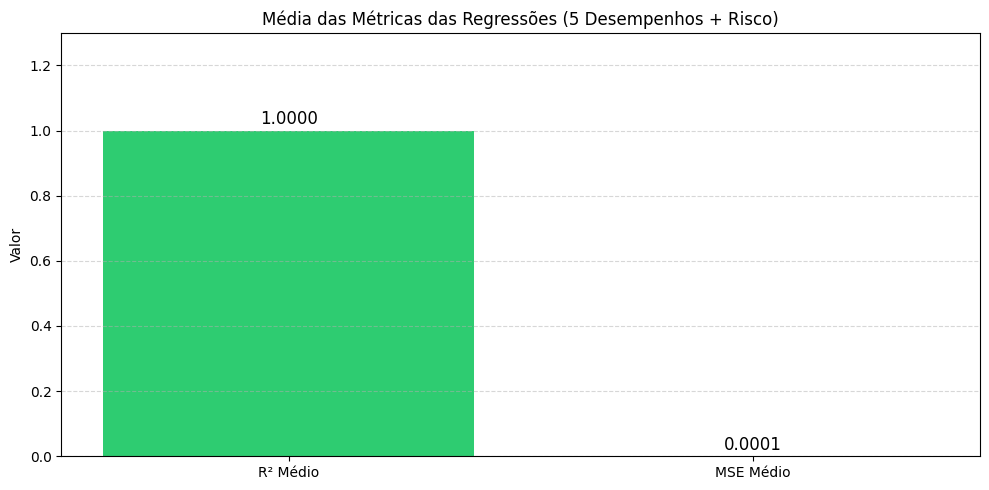

Este trecho utiliza Regressão Linear com penalização Ridge para prever o desempenho dos alunos em cinco avaliações e o risco de evasão. A escolha da regressão Ridge se dá pela sua capacidade de lidar com multicolinearidade entre variáveis preditoras, o que é comum em bases com múltiplos atributos educacionais. Foram aplicadas duas métricas para avaliação dos modelos: R² (coeficiente de determinação): mede quanto da variação do target pode ser explicada pelas variáveis independentes. Quanto mais próximo de 1, melhor o modelo. MSE (Mean Squared Error): mede a média dos erros ao quadrado entre as previsões e os valores reais. Quanto menor, melhor a precisão. A previsão de desempenho ajuda a identificar alunos que estão com dificuldades específicas ao longo dos bimestres. Já a regressão do risco (quando tratada como contínua) serve para entender a influência de variáveis como idade, curso, sexo e desempenho sobre a chance de evasão. Estes resultados alimentam estratégias de intervenção mai

In [27]:
# ===============================
# REGRESSÃO LINEAR (RIDGE) PARA DESEMPENHO E RISCO DE EVASÃO
# ===============================

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cópia do DataFrame para não modificar o original
df_model = df.copy()

# Variáveis-alvo para regressão
targets_reg = ['notas_1', 'notas_2', 'notas_3', 'notas_4', 'notas_5', 'risco_evasao']

resultados_r2 = []
resultados_mse = []

for target in targets_reg:
    if target not in df_model.columns:
        print(f"Coluna {target} não encontrada no DataFrame, pulando.")
        continue

    # Colunas que não serão usadas como features
    features_to_drop = targets_reg + ['aluno_id', 'nome_aluno', 'email']
    # Adiciona colunas de professores (se existirem e não forem alvos)
    for i in range(1, 6):
        prof_col = f'professor_{i}'
        if prof_col in df_model.columns and prof_col not in targets_reg:
            features_to_drop.append(prof_col)

    # Garantir que o target não seja removido
    if target in features_to_drop:
        features_to_drop.remove(target)

    X_reg = df_model.drop(columns=features_to_drop, errors='ignore')
    y_reg = df_model[target]

    # Remove linhas com target nulo
    valid_indices = y_reg.dropna().index
    X_reg = X_reg.loc[valid_indices]
    y_reg = y_reg.loc[valid_indices]

    # Verifica variabilidade do target
    if y_reg.nunique() < 2:
        print(f"Coluna {target} não tem variação suficiente ({y_reg.nunique()} valores únicos) para regressão após remover nulos.")
        continue

    # Caso target seja categórico, aplica LabelEncoder (para robustez)
    if y_reg.dtype == 'object':
        print(f"Aviso: Target '{target}' é do tipo object. Aplicando LabelEncoder.")
        le = LabelEncoder()
        y_reg = le.fit_transform(y_reg)
        if len(set(y_reg)) < 2:
            print(f"Coluna {target} não tem variação suficiente após Label Encoding.")
            continue

    # One-hot encoding para variáveis categóricas em X_reg
    cols_obj = X_reg.select_dtypes(include='object').columns.tolist()
    if 'risco_evasao' in cols_obj and target != 'risco_evasao':
        cols_obj.remove('risco_evasao')  # Evita dummy do target

    X_reg_encoded = pd.get_dummies(X_reg, columns=cols_obj, drop_first=True)

    # Divisão treino/teste
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_reg_encoded, y_reg, test_size=0.2, random_state=42
    )

    # Pipeline: imputação, escala e regressão ridge
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', Ridge())
    ])

    pipeline.fit(X_train_r, y_train_r)
    y_pred_r = pipeline.predict(X_test_r)

    if len(y_test_r) > 0:
        try:
            y_test_r_num = pd.to_numeric(y_test_r, errors='coerce')
            y_pred_r_num = pd.to_numeric(y_pred_r, errors='coerce')

            valid_idx = ~np.isnan(y_test_r_num) & ~np.isnan(y_pred_r_num)
            y_test_r_valid = y_test_r_num[valid_idx]
            y_pred_r_valid = y_pred_r_num[valid_idx]

            if len(y_test_r_valid) > 0:
                r2 = r2_score(y_test_r_valid, y_pred_r_valid)
                mse = mean_squared_error(y_test_r_valid, y_pred_r_valid)

                resultados_r2.append(r2)
                resultados_mse.append(mse)

                print(f"{target} - R²: {r2:.4f}, MSE: {mse:.4f}")
            else:
                print(f"Não há valores válidos para cálculo de métricas para '{target}'")
        except Exception as e:
            print(f"Erro ao calcular métricas para {target}: {e}")
    else:
        print(f"Conjunto de teste para '{target}' está vazio.")

# Cálculo e exibição das médias das métricas
if resultados_r2:
    media_r2 = np.mean(resultados_r2)
    media_mse = np.mean(resultados_mse)

    print(f"\nMédia dos R²: {media_r2:.4f}")
    print(f"Média dos MSE: {media_mse:.4f}")

    # Plot das médias
    plt.figure(figsize=(10, 5))
    barras = plt.bar(['R² Médio', 'MSE Médio'], [media_r2, media_mse], color=['#2ecc71', '#e74c3c'])
    plt.title("Média das Métricas das Regressões (5 Desempenhos + Risco)")
    plt.ylabel("Valor")

    # Ajusta limite inferior em zero para evitar barra negativa que não faz sentido para R² e MSE
    plt.ylim(0, max(media_r2, media_mse) * 1.3)

    # Adiciona valores acima das barras
    for barra in barras:
        altura = barra.get_height()
        plt.text(barra.get_x() + barra.get_width() / 2, altura + 0.02, f"{altura:.4f}", ha='center', fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma regressão válida foi executada. Verifique os targets e dados.")

print(
    "Este trecho utiliza Regressão Linear com penalização Ridge para prever o desempenho dos alunos "
    "em cinco avaliações e o risco de evasão. A escolha da regressão Ridge se dá pela sua capacidade "
    "de lidar com multicolinearidade entre variáveis preditoras, o que é comum em bases com múltiplos "
    "atributos educacionais. Foram aplicadas duas métricas para avaliação dos modelos: R² (coeficiente de determinação): "
    "mede quanto da variação do target pode ser explicada pelas variáveis independentes. Quanto mais próximo de 1, melhor o modelo. "
    "MSE (Mean Squared Error): mede a média dos erros ao quadrado entre as previsões e os valores reais. Quanto menor, melhor a precisão. "
    "A previsão de desempenho ajuda a identificar alunos que estão com dificuldades específicas ao longo dos bimestres. "
    "Já a regressão do risco (quando tratada como contínua) serve para entender a influência de variáveis como idade, curso, sexo e desempenho "
    "sobre a chance de evasão. Estes resultados alimentam estratégias de intervenção mais personalizadas e eficientes."
)

# Debug final com tipos e shapes
print(f"Tipo de y_test_r: {type(y_test_r)}, Tipo de y_pred_r: {type(y_pred_r)}")
print(f"Shape y_test_r: {y_test_r.shape if hasattr(y_test_r, 'shape') else len(y_test_r)}")
print(f"Shape y_pred_r: {y_pred_r.shape if hasattr(y_pred_r, 'shape') else len(y_pred_r)}")
print(f"Valores únicos em y_test_r: {pd.unique(y_test_r)}")

# ===============================
# Fim Regressão Linear
# ===============================


In [28]:
# -------------------------------
# Clusterização com KMeans e PCA
# -------------------------------

# Neste projeto, utilizamos técnicas de Clusterização (KMeans) e Classificação supervisionada (Random Forest)
# para analisar dados acadêmicos dos alunos e prever seus desempenhos e riscos de evasão.

# A clusterização serve para identificar padrões e grupos de comportamento natural entre os alunos, sem rótulos.
# Já a classificação supervisionada prevê variáveis específicas (ex: desempenho, evasão), utilizando dados previamente rotulados.

# O uso do PCA (Análise de Componentes Principais) reduz a dimensionalidade dos dados para facilitar a visualização dos clusters.

# SMOTE é aplicado para balancear o conjunto de dados, garantindo que as classes menos frequentes sejam bem representadas
# e evitando que o modelo fique tendencioso para a classe majoritária.

# A Random Forest foi escolhida pela sua robustez, capacidade de lidar bem com variáveis categóricas e numéricas
# e por ser menos propensa a overfitting, além de oferecer interpretação de importância das variáveis.

# O pipeline de pré-processamento permite preparar os dados de forma organizada e segura,
# evitando vazamento de dados e garantindo compatibilidade com os modelos.

# As métricas utilizadas foram:
# - Silhouette Score: para avaliar a qualidade dos clusters formados.
# - Classification Report: que exibe precisão, recall, f1-score e suporte de cada classe predita pelo modelo supervisionado.
# Este pipeline ilustra um fluxo completo de machine learning:
#  1 Clusterização exploratória sem supervisão com KMeans + PCA.
#  2 Definição e preparação de features e target para classificação supervisionada.
#  3 Pré-processamento organizado via pipelines.
#  4 Balanceamento de classes com SMOTE.
#  5 Treinamento com RandomForest robusto e ajustado.
#  6 Avaliação detalhada com métricas interpretáveis.

# Esse processo permite realizar tanto análises exploratórias quanto preditivas
# sobre desempenho e evasão de alunos, gerando insights e ações práticas para a instituição.

# Inicialização do algoritmo KMeans para formar 3 clusters.
# O parâmetro random_state garante reprodutibilidade dos resultados.
kmeans = KMeans(n_clusters=3, random_state=42)

# Ajuste do modelo KMeans aos dados escalados e predição dos clusters para cada ponto.
clusters = kmeans.fit_predict(X_scaled)

# Cálculo do Silhouette Score para avaliar a qualidade dos clusters.
# O Silhouette Score varia entre -1 e 1; quanto mais próximo de 1, melhor definido o cluster.
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

# Redução da dimensionalidade dos dados para 2 componentes principais com PCA para visualização.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Criação de DataFrame para plotagem, incluindo os dois componentes PCA e o cluster atribuído.
df_plot = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': clusters
})

# Visualização interativa dos clusters em 2D usando Plotly Express.
# Cada ponto representa um aluno, colorido conforme o cluster.
fig = px.scatter(
    df_plot, x='PCA1', y='PCA2',
    color=df_plot['Cluster'].astype(str),
    title='Clusters dos Alunos (KMeans + PCA)',
    color_discrete_sequence=px.colors.qualitative.Set2
)

# Ajuste estético dos marcadores no gráfico para melhor visualização.
fig.update_traces(marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')))
fig.show()

# -------------------------------------------------
# Preparação das variáveis para modelagem supervisionada
# -------------------------------------------------

# Lista de features (variáveis independentes) usadas no modelo,
# incluindo características demográficas, socioeconômicas e dados das 5 primeiras aulas.
features = [
    'sexo', 'idade', 'trabalha', 'renda_familiar', 'acompanhamento_medico',
    'tem_filho', 'estado_civil', 'curso', 'status', 'turma',
    'semestre', 'bimestre',
    'aula_1', 'professor_1', 'notas_1', 'faltas_1',
    'aula_2', 'professor_2', 'notas_2', 'faltas_2',
    'aula_3', 'professor_3', 'notas_3', 'faltas_3',
    'aula_4', 'professor_4', 'notas_4', 'faltas_4',
    'aula_5', 'professor_5', 'notas_5', 'faltas_5'
]

# Target é a variável alvo do modelo. Pode ser 'desempenho_1' (desempenho inicial),
# 'risco_evasao' (indicador de evasão) ou 'desempenho_final', dependendo do objetivo.
target = 'desempenho_1'  # alterar conforme objetivo do experimento

# Remove registros que não possuem valor na variável target para evitar erros no treino.
df_valid = df.dropna(subset=[target])
X = df_valid[features]
y = df_valid[target]

# Identificação das colunas categóricas e numéricas para aplicar pré-processamento adequado.
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

# -----------------------------
# Pipelines de pré-processamento
# -----------------------------

# Pipeline para variáveis categóricas:
# 1) Imputa valores faltantes pela moda (valor mais frequente)
# 2) Codifica variáveis categóricas em variáveis dummy (OneHotEncoder),
#    ignorando categorias desconhecidas no teste.
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline para variáveis numéricas:
# 1) Imputa valores faltantes pela mediana
# 2) Escala os dados para média 0 e desvio padrão 1 (StandardScaler)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Aplica os pipelines separadamente nas colunas categóricas e numéricas,
# garantindo que o modelo receba dados limpos e numéricos.
preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols),
    ('num', num_pipeline, num_cols)
])

# --------------------------
# Separação treino e teste
# --------------------------

# Divisão estratificada dos dados em treino (80%) e teste (20%) para manter a proporção das classes.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Aplicação do pré-processamento nos dados de treino e teste,
# garantindo que a transformação seja ajustada apenas no treino (fit_transform) e aplicada no teste (transform).
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# -------------------------
# Balanceamento com SMOTE
# -------------------------

# SMOTE (Synthetic Minority Over-sampling Technique) cria amostras sintéticas da classe minoritária
# para balancear o conjunto de treino e evitar que o modelo seja enviesado para a classe majoritária.
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

# -----------------------------------
# Treinamento do classificador RandomForest
# -----------------------------------

# RandomForest é um modelo robusto de ensemble que melhora a acurácia e reduz overfitting.
# O parâmetro class_weight='balanced' reforça o aprendizado em classes minoritárias.
clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf.fit(X_train_res, y_train_res)

# --------------------------------------
# Avaliação no conjunto de teste original
# --------------------------------------

# Realiza predição no conjunto de teste não balanceado (dados reais).
y_pred = clf.predict(X_test_prep)

# Gera relatório detalhado com métricas de classificação:
# precisão, recall, f1-score e suporte para cada classe.
print("Relatório de Classificação (RandomForest + SMOTE no treino):")
print(classification_report(y_test, y_pred))

# -----------------------------------
# Imports para uso posterior no Spark ML
# -----------------------------------

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix

print("Clusterização KMeans + PCA: ajuda a explorar e entender padrões e grupos naturais nos dados dos alunos sem supervisão. O PCA facilita visualização e análise dos clusters, já que os dados originais são de alta dimensionalidade. Pré-processamento com pipelines: evita vazamento de dados (data leakage) e garante tratamento correto dos dados categóricos e numéricos, preparando o dataset para algoritmos que exigem entrada numérica. SMOTE: fundamental para balancear classes em problemas com desbalanceamento, como evasão escolar, evitando que o modelo aprenda um viés e melhore sua capacidade preditiva para todas as classes. RandomForest com class_weight: combinação que promove robustez e sensibilidade a classes minoritárias, importante para problemas reais onde classes menos frequentes são críticas.Relatório de classificação: fornece métricas essenciais para avaliar performance do modelo além da simples acurácia, destacando o desempenho por classe.")


Silhouette Score: 0.037880192267609414


Relatório de Classificação (RandomForest + SMOTE no treino):
              precision    recall  f1-score   support

         Bom       0.84      0.61      0.71       130
   Excelente       0.96      0.51      0.67        94
     Regular       0.87      0.96      0.91       466
        Ruim       0.98      1.00      0.99      1310

    accuracy                           0.94      2000
   macro avg       0.91      0.77      0.82      2000
weighted avg       0.94      0.94      0.94      2000

Clusterização KMeans + PCA: ajuda a explorar e entender padrões e grupos naturais nos dados dos alunos sem supervisão. O PCA facilita visualização e análise dos clusters, já que os dados originais são de alta dimensionalidade. Pré-processamento com pipelines: evita vazamento de dados (data leakage) e garante tratamento correto dos dados categóricos e numéricos, preparando o dataset para algoritmos que exigem entrada numérica. SMOTE: fundamental para balancear classes em problemas com desbalanceament

In [33]:
# ------------------------------
# Importações necessárias
# ------------------------------
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd

# ------------------------------
# Montar o Google Drive (se estiver no Colab)
# ------------------------------
from google.colab import drive
drive.mount('/content/drive')

# ------------------------------
# Inicialização da sessão Spark
# ------------------------------
spark = SparkSession.builder \
    .appName("PrevisaoRiscoEvasao") \
    .getOrCreate()

# ------------------------------
# Leitura dos dados do CSV no Google Drive
# ------------------------------
df_spark = spark.read.option("header", "true").option("inferSchema", "true") \
    .csv("/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv")

# Conferência dos dados
df_spark.printSchema()
df_spark.show(5)

# ------------------------------
# Definição das colunas numéricas e categóricas
# ------------------------------
colunas_numericas = ["idade", "renda_familiar", "faltas_1", "notas_1", "faltas_2", "notas_2",
                     "faltas_3", "notas_3", "faltas_4", "notas_4", "faltas_5", "notas_5"]

colunas_categoricas = ["sexo", "trabalha", "acompanhamento_medico", "tem_filho",
                      "estado_civil", "desempenho_1", "desempenho_2",
                      "desempenho_3", "desempenho_4", "desempenho_5", "risco_evasao"]

# ------------------------------
# Conversão de tipos e tratamento de valores ausentes
# ------------------------------
for coln in colunas_numericas:
    df_spark = df_spark.withColumn(coln, col(coln).cast("double"))
    df_spark = df_spark.na.fill({coln: -1})

for colc in colunas_categoricas:
    df_spark = df_spark.na.fill({colc: "desconhecido"})
    indexer = StringIndexer(inputCol=colc, outputCol=colc + "_idx", handleInvalid="keep")
    df_spark = indexer.fit(df_spark).transform(df_spark)

# ------------------------------
# Montagem do vetor de features
# ------------------------------
feature_cols = colunas_numericas + [col + "_idx" for col in colunas_categoricas[:-1]]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_vec")
df_spark = assembler.transform(df_spark)

# ------------------------------
# Treinamento do modelo Random Forest
# ------------------------------
rf = RandomForestClassifier(labelCol="risco_evasao_idx", featuresCol="features_vec")
model = rf.fit(df_spark)

# ------------------------------
# Realiza predições e avalia o modelo
# ------------------------------
predictions = model.transform(df_spark)

evaluator = MulticlassClassificationEvaluator(
    labelCol="risco_evasao_idx", predictionCol="prediction", metricName="accuracy"
)
accuracy = evaluator.evaluate(predictions)
print(f"Acurácia do modelo: {accuracy:.4f}")

# ------------------------------
# Se quiser fazer a simulação MapReduce no Pandas
# ------------------------------
# Leitura via Pandas para MapReduce
df_pd = pd.read_csv("/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv")

def mapper(linhas):
    pares = []
    for linha in linhas:
        if pd.notna(linha):
            for aula_1 in linha.replace("[", "").replace("]", "").replace("'", "").split(","):
                aula_1 = aula_1.strip()
                pares.append((aula_1, 1))
    return pares

def shuffle(mapped_data):
    agrupado = {}
    for chave, valor in mapped_data:
        agrupado.setdefault(chave, []).append(valor)
    return agrupado

def reducer(agrupado):
    return {chave: sum(valores) for chave, valores in agrupado.items()}

mapped = mapper(df_pd["aula_1"])
shuffled = shuffle(mapped)
reduced = reducer(shuffled)

print("Contagem de aulas via MapReduce simulado:")
print(reduced)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
root
 |-- aluno_id: integer (nullable = true)
 |-- nome_aluno: string (nullable = true)
 |-- email_aluno: string (nullable = true)
 |-- curso: string (nullable = true)
 |-- status: string (nullable = true)
 |-- turma: string (nullable = true)
 |-- sexo: string (nullable = true)
 |-- idade: double (nullable = true)
 |-- trabalha: integer (nullable = true)
 |-- renda_familiar: long (nullable = true)
 |-- acompanhamento_medico: integer (nullable = true)
 |-- tem_filho: integer (nullable = true)
 |-- estado_civil: string (nullable = true)
 |-- semestre: integer (nullable = true)
 |-- bimestre: integer (nullable = true)
 |-- aula_1: string (nullable = true)
 |-- professor_1: string (nullable = true)
 |-- notas_1: double (nullable = true)
 |-- faltas_1: integer (nullable = true)
 |-- desempenho_1: string (nullable = true)
 |-- aula_2: string (nullable = true)
 |-- 

In [34]:
# -------------------------
# Gráfico de frequência das aulas (MapReduce Simulado)
# -------------------------
# Transforma o dicionário com contagem de aulas em DataFrame.
# Ordena por número de ocorrências para melhor visualização.
# Gráfico de barras mostra quais aulas aparecem mais nos dados,
# útil para entender distribuição e concentração de dados.
df_aulas = pd.DataFrame(list(reduced.items()), columns=["Aula", "Ocorrencias"])
fig_aulas = px.bar(df_aulas.sort_values(by="Ocorrencias", ascending=False),
                   x="Aula", y="Ocorrencias",
                   title="Frequência de Aulas (MapReduce Simulado)")
fig_aulas.show()

# -------------------------
# HBase Simulado: estrutura chave-valor
# -------------------------
# Cria um dicionário simulando a estrutura de uma tabela HBase.
# Cada registro recebe uma chave única (ex: "desempenhos:0") e famílias de colunas (ex: info:aula).
# Exemplo prático para mostrar como dados não-relacionais podem ser organizados para rápido acesso.
hbase = {
    f"desempenhos:{i}": {
        "info:aula": str(row["aula_2"]),
        "info:desempenho": str(row["desempenho_2"]),
        "info:faltas": str(row["faltas_2"])
    }
    for i, row in df.iterrows()
}

# -------------------------
# Sqoop Simulado: exportação e importação de dados
# -------------------------
# Utiliza banco SQLite em memória para simular importação/exportação de dados.
# Exporta subset dos dados para uma tabela SQL e lê novamente.
# Depois exporta para CSV, simulando movimentação entre MySQL e HDFS via Sqoop.
conn = sqlite3.connect(":memory:")
df[["aula_2", "desempenho_2", "faltas_2"]].to_sql("Aula2", conn, if_exists="replace", index=False)
df_sql = pd.read_sql("SELECT * FROM Aula2", conn)
df_sql.to_csv("Aula2_hdfs.csv", index=False)

# -------------------------
# Regras manuais para definir risco de evasão
# -------------------------
# Aplica regras de negócio simples baseadas em faltas, notas e renda familiar.
# Risco "Alto" se faltas >10 ou notas <5 ou renda muito baixa (<1500).
# "Médio" para casos intermediários, "Baixo" caso contrário.
# Permite criar um target categórico para análise e treinamento ML.
df['faltas_1'] = pd.to_numeric(df['faltas_1'], errors='coerce')
df['notas_1'] = pd.to_numeric(df['notas_1'], errors='coerce')
df['renda_familiar'] = pd.to_numeric(df['renda_familiar'], errors='coerce')

df['risco_evasao'] = df.apply(
    lambda row: 'Alto' if (row['faltas_1'] > 10 or row['notas_1'] < 5 or row['renda_familiar'] < 1500)
    else 'Médio' if (row['faltas_1'] > 5 or row['notas_1'] < 7)
    else 'Baixo',
    axis=1
)

In [35]:
# -------------------------
# Gráfico: distribuição percentual do risco de evasão
# -------------------------
# Conta as ocorrências relativas de cada categoria de risco.
# Gráfico de pizza facilita visualização rápida da proporção de alunos em cada risco.
# Ajuda stakeholders a entenderem o panorama geral.
df_risco = df['risco_evasao'].value_counts(normalize=True).reset_index()
df_risco.columns = ['Risco', 'Percentual']
df_risco['Percentual'] = df_risco['Percentual'] * 100

fig_risco = px.pie(df_risco, names='Risco', values='Percentual',
                   title='Distribuição do Risco de Evasão (baseado em regras)',
                   color_discrete_sequence=px.colors.qualitative.Set1)
fig_risco.update_traces(textinfo='percent+label')
fig_risco.show()

In [36]:
# -------------------------
# Gráfico: Classe econômica vs risco de evasão
# -------------------------
# Cria categorias econômicas baseadas em faixa de renda familiar.
# Exibe histograma agrupado pela classe econômica e cor por nível de risco.
# Útil para identificar correlações entre condição socioeconômica e evasão.
df['classe_economica'] = pd.cut(df['renda_familiar'],
                                bins=[-np.inf, 4000, 8000, np.inf],
                                labels=['Baixa', 'Média', 'Alta'])

fig_classe = px.histogram(df.dropna(subset=['classe_economica', 'risco_evasao']),
                          x='classe_economica', color='risco_evasao',
                          barmode='group',
                          title='Classe Econômica vs Risco de Evasão')
fig_classe.update_layout(bargap=0.2)
fig_classe.show()

In [37]:
# -------------------------
# Gráfico: Número de faltas vs risco de evasão
# -------------------------
# Histograma que mostra a distribuição de faltas agrupada pelo risco.
# Permite verificar se maior número de faltas está associado a maior risco.
df_faltas = df.dropna(subset=['faltas_1', 'risco_evasao'])
df_faltas['faltas_1'] = df_faltas['faltas_1'].astype(int)

fig_faltas = px.histogram(df_faltas, x='faltas_1', color='risco_evasao',
                          title='Número de Faltas vs Risco de Evasão',
                          nbins=20)
fig_faltas.show()

print("Os gráficos são fundamentais para explorar e comunicar os dados e os insights do projeto. A simulação de HBase e Sqoop demonstra conceitos de big data e integração entre sistemas. A definição manual de regras de risco gera uma variável target que pode ser usada para treinamentos futuros, validação e explicação dos modelos. Visualizar riscos relacionados a fatores socioeconômicos e comportamentais (faltas, notas) é essencial para construir modelos preditivos úteis e justos.")
#==============================

Os gráficos são fundamentais para explorar e comunicar os dados e os insights do projeto. A simulação de HBase e Sqoop demonstra conceitos de big data e integração entre sistemas. A definição manual de regras de risco gera uma variável target que pode ser usada para treinamentos futuros, validação e explicação dos modelos. Visualizar riscos relacionados a fatores socioeconômicos e comportamentais (faltas, notas) é essencial para construir modelos preditivos úteis e justos.


In [38]:
# Visualizações das previsões do modelo Spark

# Coleta manual dos dados das colunas 'risco_evasao_idx' (rótulo real) e 'prediction' (rótulo previsto)
# do DataFrame Spark para posterior análise em Pandas.
data = predictions.select("risco_evasao_idx", "prediction").collect()

# Converte a lista coletada para um DataFrame Pandas para facilitar manipulações e visualizações
preds_pd = pd.DataFrame(data, columns=["risco_evasao_idx", "prediction"])

# Repetição da coleta e conversão, garantindo que temos os dados atualizados para análise
data = predictions.select("risco_evasao_idx", "prediction").collect()
preds_pd = pd.DataFrame(data, columns=["risco_evasao_idx", "prediction"])

# Coleta todos os dados do DataFrame Spark para análise mais ampla e criação de gráficos
data = df_spark.collect()
df_pandas = pd.DataFrame([row.asDict() for row in data])

# Tratamento de valores ausentes na coluna 'risco_evasao' para evitar problemas em análises e gráficos
# Preenche valores nulos com a categoria 'Desconhecido'
df_pandas['risco_evasao'] = df_pandas['risco_evasao'].fillna('Desconhecido')

# Mapeia as classes numéricas previstas pelo modelo para seus rótulos textuais correspondentes
# Isso facilita a interpretação dos resultados e a comunicação dos achados
map_labels = {0: "Baixo", 1: "Médio", 2: "Alto"}

# Converte as previsões do Spark para Pandas para facilitar operações como merge e análises detalhadas
predictions_pandas = predictions.select("aluno_id", "prediction").toPandas()
predictions_pandas['risco_predito'] = predictions_pandas['prediction'].map(map_labels)

# Ajusta os tipos das colunas 'aluno_id' para string em ambos DataFrames para garantir compatibilidade no merge
df_model['aluno_id'] = df_model['aluno_id'].astype(str)
predictions_pandas['aluno_id'] = predictions_pandas['aluno_id'].astype(str)

# Remove uma possível coluna anterior 'risco_predito' para evitar conflito de colunas no merge
if 'risco_predito' in df_model.columns:
    df_model = df_model.drop(columns=['risco_predito'])

# Junta as previsões categóricas ao DataFrame principal df_model para análise integrada
# Merge inner para manter somente alunos com previsões disponíveis
df_model = df_model.merge(predictions_pandas[['aluno_id', 'risco_predito']], on='aluno_id', how='inner')

print("Colunas após merge:", df_model.columns)
print(df_model.head())

# Filtra os alunos classificados com risco 'Alto' para análise e intervenções específicas
alunos_alto_risco = df_model[df_model['risco_predito'] == 'Alto']
print(alunos_alto_risco[['nome_aluno', 'desempenho_1', 'faltas_1', 'notas_1']].head())

# Cálculo da distribuição percentual dos riscos preditos para entender a proporção de cada categoria no conjunto
risco_counts = df_model['risco_predito'].value_counts(normalize=True) * 100

# Prepara os dados para visualização gráfica em barras
df_risco_counts = risco_counts.reset_index()
df_risco_counts.columns = ['risco_predito', 'percentual']

Colunas após merge: Index(['aluno_id', 'nome_aluno', 'email_aluno', 'curso', 'status', 'turma',
       'sexo', 'idade', 'trabalha', 'renda_familiar', 'acompanhamento_medico',
       'tem_filho', 'estado_civil', 'semestre', 'bimestre', 'aula_1',
       'professor_1', 'notas_1', 'faltas_1', 'desempenho_1', 'aula_2',
       'professor_2', 'notas_2', 'faltas_2', 'desempenho_2', 'aula_3',
       'professor_3', 'notas_3', 'faltas_3', 'desempenho_3', 'aula_4',
       'professor_4', 'notas_4', 'faltas_4', 'desempenho_4', 'aula_5',
       'professor_5', 'notas_5', 'faltas_5', 'desempenho_5', 'risco_evasao',
       'risco_predito'],
      dtype='object')
  aluno_id            nome_aluno               email_aluno  \
0        1      Leandro Oliveira  ryannogueira@example.org   
1        2  Alexandre Montenegro      lpeixoto@example.com   
2        3    Sra. Joana Peixoto  ocasa-grande@example.org   
3        4   Sra. Agatha da Rosa  mcasa-grande@example.org   
4        5          Renan Macedo   tn

In [40]:
# Gráfico interativo de barras mostrando a distribuição percentual dos riscos preditos pelo modelo
# Este gráfico é fundamental para comunicar de forma clara e visual o perfil de risco dos alunos
fig = px.bar(
    df_risco_counts,
    x='risco_predito',
    y='percentual',
    color='risco_predito',
    text='percentual',
    color_discrete_sequence=px.colors.qualitative.Set1,
    title='Distribuição percentual dos riscos preditos'
)
# Configurações finais do gráfico para melhorar a legibilidade e apresentação
fig.update_layout(
    yaxis_title="Porcentagem (%)",
    xaxis_title="Risco Predito",
    showlegend=False
)

# Ajusta os textos sobre as barras para mostrar valores percentuais formatados com duas casas decimais
fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')

# Exibe o gráfico interativo
fig.show()
print("Mapeamento das classes numéricas para texto: torna o resultado do modelo compreensível para qualquer stakeholder, facilitando a comunicação. Merge das previsões com os dados originais: permite análises cruzadas, como identificar características comuns dos alunos em cada nível de risco. Distribuição percentual dos riscos preditos: importante para entender como o modelo está classificando os alunos e avaliar se a distribuição faz sentido frente ao conhecimento do domínio (por exemplo, se há muitos alunos em risco alto, pode indicar um problema na escola). Filtragem de alunos de alto risco: possibilita ações focadas, como acompanhamento especial, prevenindo evasão.")


In [41]:
# Definição das variáveis (features) que serão usadas para treinar o modelo.
# Não incluímos identificadores (ex: aluno_id) nem o target (risco_evasao),
# para garantir que o modelo aprenda apenas das variáveis preditivas.
features_all = [
    "curso", "status", "turma", "sexo", "idade", "trabalha", "renda_familiar", "acompanhamento_medico",
    "tem_filho", "estado_civil", "semestre", "bimestre",
    "aula_1", "professor_1", "notas_1", "faltas_1", "desempenho_1",
    "aula_2", "professor_2", "notas_2", "faltas_2", "desempenho_2",
    "aula_3", "professor_3", "notas_3", "faltas_3", "desempenho_3",
    "aula_4", "professor_4", "notas_4", "faltas_4", "desempenho_4",
    "aula_5", "professor_5", "notas_5", "faltas_5", "desempenho_5"
]

# Preparação dos dados para o modelo:
# X contém as features selecionadas para treino, y contém o target 'risco_evasao'.
# Essa separação é padrão em problemas supervisionados.
X = df_model[features_all].copy()
y = df_model['risco_evasao']

# Transformação de variáveis categóricas para numérico,
# usando One-Hot Encoding via get_dummies, descartando a primeira categoria para evitar multicolinearidade.
# Isso é fundamental para que algoritmos que exigem entradas numéricas possam trabalhar corretamente.
X_encoded = pd.get_dummies(X, drop_first=True)

# Para Spark ML, as features precisam ser vetorizadas em uma coluna única do tipo vetor.
# O VectorAssembler faz essa transformação, combinando todas as colunas indicadas em uma só.
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_spark = assembler.transform(df_spark)

# Treinamento do modelo RandomForest com 100 árvores,
# que é um algoritmo robusto para classificação e captura interações não lineares.
rf = RandomForestClassifier(labelCol="risco_evasao_idx", featuresCol="features", numTrees=100)
model = rf.fit(df_spark)

# Extração da importância das features para entender quais variáveis mais influenciam a predição.
# Essa análise é crucial para interpretar o modelo e gerar insights para ação.
importances = model.featureImportances.toArray()

# Obtenção dos nomes das features após transformação (vetorização)
feature_names = assembler.getInputCols()

# Organização dos dados de importância em DataFrame para facilitar visualização
df_imp = pd.DataFrame({
    'Variável': feature_names,
    'Importância': importances
}).sort_values(by='Importância', ascending=False)

In [42]:
# Visualização gráfica das 10 features mais importantes para o modelo,
# mostrando o impacto de cada uma na predição do risco de evasão.
fig = px.bar(
    df_imp.head(10),
    x='Importância',
    y='Variável',
    orientation='h',
    color='Importância',
    color_continuous_scale='Viridis',
    title='Importância das Variáveis para Predição do Risco de Evasão (PySpark)',
    labels={'Importância': 'Importância da Feature', 'Variável': 'Feature'}
)
fig.update_layout(yaxis=dict(categoryorder='total ascending'))
fig.show()

In [46]:
import pandas as pd
import numpy as np

# Cópia do DataFrame original para preservar os dados
df_plot = df.copy()

# Remove registros com dados faltantes em 'renda_familiar' ou 'risco_evasao'
df_plot = df_plot.dropna(subset=['renda_familiar', 'risco_evasao'])

# Converte 'renda_familiar' para numérico, tratando erros como NaN e removendo-os
df_plot['renda_familiar'] = pd.to_numeric(df_plot['renda_familiar'], errors='coerce')
df_plot = df_plot.dropna(subset=['renda_familiar'])

# Criação de categorias econômicas com base na renda
df_plot['classe_economica'] = pd.cut(
    df_plot['renda_familiar'],
    bins=[-np.inf, 4000, 8000, np.inf],
    labels=['Baixa', 'Média', 'Alta']
)

# Filtra apenas os alunos classificados como evadidos
df_evadidos = df_plot[df_plot['risco_evasao'].astype(str).str.lower().isin(['1', 'alto'])]

# Conta a quantidade de evadidos por classe econômica
df_contagem = df_evadidos.groupby('classe_economica', observed=False).size().reset_index(name='quantidade_evadidos')

# Garante que todas as classes econômicas estejam presentes
todas_classes = ['Baixa', 'Média', 'Alta']
df_contagem = df_contagem.set_index('classe_economica').reindex(todas_classes, fill_value=0).reset_index()

# Exibe o resultado
print(df_contagem)


  classe_economica  quantidade_evadidos
0            Baixa                 2638
1            Média                 2697
2             Alta                 1476


In [47]:
# Gráfico interativo mostrando a quantidade de alunos evadidos em cada classe econômica,
# facilitando a visualização do impacto socioeconômico na evasão.
fig = px.bar(
    df_contagem,
    x='classe_economica',
    y='quantidade_evadidos',
    labels={'classe_economica': 'Classe Econômica', 'quantidade_evadidos': 'Quantidade de Alunos Evadidos'},
    title='Quantidade de Alunos Evadidos por Classe Econômica (Renda Familiar)',
    color='classe_economica',
    color_discrete_map={'Baixa': 'red', 'Média': 'orange', 'Alta': 'green'},
    width=700,
    height=500
)

fig.update_layout(
    yaxis=dict(title='Quantidade de Alunos Evadidos', dtick=1),
    xaxis=dict(title='Classe Econômica'),
    showlegend=False,
    hoverlabel=dict(bgcolor="white", font_size=12, font_family="Arial")
)

fig.show()

print("Seleção das features: É essencial escolher variáveis que tenham potencial preditivo e que estejam relacionadas com evasão escolar. Isso melhora a acurácia e evita ruídos. Codificação de variáveis categóricas: Algoritmos como RandomForest em Spark requerem dados numéricos, logo, transformar categorias em variáveis dummy é obrigatório para o funcionamento do modelo. Importância das features: Ajuda a interpretar o modelo e entender quais fatores influenciam mais o risco, possibilitando direcionar ações educativas e políticas de prevenção. Análise socioeconômica: A relação entre renda familiar e evasão pode revelar desigualdades estruturais que influenciam o abandono escolar, importante para políticas públicas e apoio direcionado. Visualizações interativas: Facilita a exploração e comunicação dos resultados para gestores e educadores.")


Seleção das features: É essencial escolher variáveis que tenham potencial preditivo e que estejam relacionadas com evasão escolar. Isso melhora a acurácia e evita ruídos. Codificação de variáveis categóricas: Algoritmos como RandomForest em Spark requerem dados numéricos, logo, transformar categorias em variáveis dummy é obrigatório para o funcionamento do modelo. Importância das features: Ajuda a interpretar o modelo e entender quais fatores influenciam mais o risco, possibilitando direcionar ações educativas e políticas de prevenção. Análise socioeconômica: A relação entre renda familiar e evasão pode revelar desigualdades estruturais que influenciam o abandono escolar, importante para políticas públicas e apoio direcionado. Visualizações interativas: Facilita a exploração e comunicação dos resultados para gestores e educadores.


In [48]:
# --- Preparação e análise da evasão escolar relacionada ao número de faltas ---

# Filtra os dados originais para remover registros com valores ausentes em 'faltas_1' ou 'risco_evasao',
# garantindo que a análise seja feita apenas com dados completos.
df_faltas = df.copy().dropna(subset=['faltas_1', 'risco_evasao'])

# Filtra o subconjunto de alunos que efetivamente evadiram,
# identificados pelo valor "1" ou "alto" na coluna 'risco_evasao'.
df_evadidos = df_faltas[df_faltas['risco_evasao'].astype(str).str.lower().isin(['1', 'alto'])].copy()

# Converte a coluna 'faltas_1' para numérico, forçando valores inválidos para NaN,
# que são removidos em seguida para manter a integridade dos dados.
df_evadidos.loc[:, 'faltas_1'] = pd.to_numeric(df_evadidos['faltas_1'], errors='coerce')
df_evadidos = df_evadidos.dropna(subset=['faltas_1'])

# Conta a quantidade de alunos que evadiram para cada número distinto de faltas,
# permitindo observar se há uma relação entre o absenteísmo e a evasão.
df_faltas_count = df_evadidos.groupby('faltas_1').size().reset_index(name='quantidade_evadidos')

# Ordena os dados por número de faltas para melhorar a visualização no gráfico.
df_faltas_count = df_faltas_count.sort_values(by='faltas_1')


In [49]:
# Gera gráfico interativo de barras que mostra a quantidade de alunos evadidos para cada número de faltas,
# facilitando a análise visual da influência do absenteísmo na evasão escolar.
fig = px.bar(
    df_faltas_count,
    x='faltas_1',
    y='quantidade_evadidos',
    labels={'faltas_1': 'Número de Faltas', 'quantidade_evadidos': 'Quantidade de Alunos Evadidos'},
    title='Quantidade de Alunos Evadidos por Número de Faltas',
    width=800,
    height=500
)
fig.update_layout(
    xaxis=dict(dtick=1),  # Exibe todas as faltas inteiras no eixo X para melhor leitura.
    yaxis=dict(dtick=1),
    hoverlabel=dict(bgcolor="white", font_size=12, font_family="Arial")
)
fig.show()

# Texto explicativo:
# A análise da evasão escolar em função do número de faltas possibilita identificar se o absenteísmo é um fator
# preponderante para a evasão. Geralmente, um maior número de faltas está associado a maior risco de evasão,
# pois indica desengajamento do aluno. Esse insight é essencial para direcionar políticas de acompanhamento
# e intervenção para alunos com altos índices de faltas, visando reduzir a evasão.

# -----------------------------------------------------------------------------------------------------

In [50]:
# --- Preparação e análise da evasão escolar por semestre ---

# Copia os dados removendo registros com valores nulos nas colunas 'semestre' e 'risco_evasao'
df_evasao = df.copy().dropna(subset=['semestre', 'risco_evasao'])

# Filtra alunos com alto risco de evasão ('1' ou 'alto'), para focar na população de interesse.
df_evasao = df_evasao[df_evasao['risco_evasao'].astype(str).str.lower().isin(['1', 'alto'])]

# Remove registros sem semestre definido para garantir análise consistente.
df_evasao = df_evasao.dropna(subset=['semestre'])

# Conta o total de evasões por semestre, identificando em quais períodos ocorre maior evasão.
evasao_por_semestre = df_evasao['semestre'].value_counts().reset_index()
evasao_por_semestre.columns = ['semestre', 'total_evasoes']

# Conta o total de alunos matriculados por semestre, necessário para cálculo do percentual de evasão.
total_alunos_por_semestre = df['semestre'].value_counts().reset_index()
total_alunos_por_semestre.columns = ['semestre', 'total_alunos']

# Junta os dados para calcular o percentual de evasão em cada semestre,
# importante para dimensionar o impacto relativo da evasão, não apenas o valor absoluto.
dados_plot = evasao_por_semestre.merge(total_alunos_por_semestre, on='semestre')
dados_plot['percentual_evasao'] = (dados_plot['total_evasoes'] / dados_plot['total_alunos'] * 100).round(1)

In [51]:
# Gera gráfico interativo de barras comparando o total e o percentual de evasão por semestre,
# permitindo observar tendências e períodos críticos para evasão.
fig = px.bar(
    dados_plot,
    x='semestre',
    y=['total_evasoes', 'percentual_evasao'],
    barmode='group',
    title='Distribuição de Evasão por Semestre',
    labels={
        'semestre': 'Semestre',
        'value': 'Contagem/Percentual',
        'variable': 'Métrica'
    },
    color_discrete_sequence=['#e74c3c', '#3498db'],
    text_auto=True,
    width=900,
    height=500
)

fig.update_layout(
    xaxis=dict(
        title='Semestre',
        type='category',
        tickmode='linear'
    ),
    yaxis_title="Valor",
    legend_title="Métrica",
    hovermode="x unified",
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    )
)

# Renomeia legendas para facilitar entendimento da visualização.
fig.for_each_trace(lambda t: t.update(name='Total de Evasões' if t.name == 'total_evasoes' else 'Percentual de Evasão (%)'))

# Ajusta informações exibidas no tooltip para melhor contextualização ao passar o mouse.
fig.update_traces(
    textposition='outside',
    hovertemplate=(
        "<b>Semestre %{x}</b><br><br>" +
        "Total de evasões: %{y}<br>" +
        "Percentual: %{customdata[0]}%<extra></extra>"
    ),
    customdata=dados_plot[['percentual_evasao']]
)

fig.show()

# Texto explicativo:
# A análise da evasão por semestre permite identificar em quais períodos do curso a evasão é mais crítica.
# O uso do percentual de evasão oferece uma visão relativa que ajusta o tamanho da turma em cada semestre,
# possibilitando intervenções específicas em semestres mais vulneráveis. Essa métrica é fundamental para
# planejamento acadêmico e ações preventivas direcionadas, contribuindo para a redução da evasão e melhoria
# do aproveitamento escolar.


In [52]:
# --- Visualização interativa com PCA e RandomForest ---

# Cria um DataFrame com as duas primeiras componentes principais (PC1 e PC2) obtidas por PCA,
# que são combinações lineares das variáveis originais que explicam a maior parte da variância.
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Adiciona informações dos clusters obtidos e a classificação de risco predito pelo modelo RandomForest,
# permitindo a visualização da distribuição dos alunos segundo a análise de agrupamento e risco.
df_pca['Cluster'] = clusters
df_pca['Risco_Predito'] = df_model['risco_predito']

# Gráfico interativo de dispersão (scatter plot) que posiciona alunos segundo os componentes principais,
# coloridos pelo risco predito, facilitando a visualização da separação dos grupos e análise exploratória.
fig = px.scatter(
    df_pca, x='PC1', y='PC2', color='Risco_Predito',
    title='Alunos por Risco de Evasão (PCA + RandomForest)',
    labels={'PC1':'Componente Principal 1', 'PC2':'Componente Principal 2'}
)
fig.show()

In [56]:
#GRAFICO COM ERRO


# Garante que faltas, desempenho e renda sejam numéricos
df_model['faltas_1'] = pd.to_numeric(df_model['faltas_1'], errors='coerce')
df_model['desempenho_1'] = pd.to_numeric(df_model['desempenho_1'], errors='coerce')
df_model['renda_familiar'] = pd.to_numeric(df_model['renda_familiar'], errors='coerce')

# Remove dados incompletos
df_model = df_model.dropna(subset=['faltas_1', 'desempenho_1', 'renda_familiar'])

# Aplica classificação dos motivos
def definir_motivo(row):
    if row['faltas_1'] > 10:
        return 'Faltas Excessivas'
    elif row['desempenho_1'] < 5:
        return 'Baixo Desempenho'
    elif row['renda_familiar'] < 1500:
        return 'Baixa Renda'
    else:
        return 'Outro'

df_model['motivo_evasao'] = df_model.apply(definir_motivo, axis=1)

# Conta quantos alunos se encaixam em cada motivo
df_motivos = df_model['motivo_evasao'].value_counts().reset_index()
df_motivos.columns = ['motivo_evasao', 'quantidade']

# Gráfico de barras simples
fig = px.bar(
    df_motivos,
    x='motivo_evasao',
    y='quantidade',
    text='quantidade',
    title='Principais Motivos de Evasão Escolar',
    labels={'motivo_evasao': 'Motivo de Evasão', 'quantidade': 'Número de Alunos'},
    color='motivo_evasao',
    color_discrete_map={
        'Faltas Excessivas': 'crimson',
        'Baixo Desempenho': 'orange',
        'Baixa Renda': 'darkblue',
        'Outro': 'gray'
    },
    width=700,
    height=500
)

fig.update_layout(
    xaxis_title='Motivo de Evasão',
    yaxis_title='Número de Alunos',
    showlegend=False,
    hoverlabel=dict(bgcolor="white", font_size=12, font_family="Arial")
)

fig.show()


In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from nltk.corpus import stopwords
import nltk
import plotly.express as px

# Baixa stopwords se ainda não tiver
nltk.download('stopwords')
stop_words = stopwords.words('portuguese')

# --- Preparação do texto (coluna 'texto_pln') ---
df['texto_pln'] = (
    df[['aula_1', 'aula_2', 'aula_3', 'aula_4', 'aula_5',
        'professor_1', 'professor_2', 'professor_3', 'professor_4', 'professor_5']]
    .fillna('')  # Substitui nulos por vazio
    .agg(' '.join, axis=1)
)

# Remove linhas com texto ou risco ausente
df_pln = df[['texto_pln', 'risco_evasao']].dropna()

X_texto = df_pln['texto_pln']
y_risco = df_pln['risco_evasao']

# Divide em treino e teste com estratificação para manter proporção de classes
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    X_texto, y_risco, test_size=0.2, random_state=42, stratify=y_risco
)

# Vetoriza texto para treino (fit) e teste (transform)
tfidf = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,2), min_df=3, max_df=0.8)
X_train_vec = tfidf.fit_transform(X_train_txt)
X_test_vec = tfidf.transform(X_test_txt)

# Aplica SMOTE para balancear classes no treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_vec, y_train_txt)

# Cria e treina classificador Random Forest
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_res, y_train_res)

# Faz predições
y_pred = clf.predict(X_test_vec)

# Imprime relatório de classificação sem warnings (zero_division=0)
print("📊 Relatório de Classificação (PLN - Aulas e Professores):")
print(classification_report(y_test_txt, y_pred, zero_division=0))

# --- Visualização das principais palavras indicativas para cada classe ---
# RandomForest não tem coeficientes por palavra, mas tem importância global das features (palavras).

feature_names = tfidf.get_feature_names_out()
importances = clf.feature_importances_



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


📊 Relatório de Classificação (PLN - Aulas e Professores):
              precision    recall  f1-score   support

        Alto       0.70      0.28      0.40      1378
       Baixo       0.10      0.27      0.14       202
       Médio       0.21      0.45      0.29       420

    accuracy                           0.31      2000
   macro avg       0.34      0.33      0.28      2000
weighted avg       0.54      0.31      0.35      2000



In [64]:
# Cria dataframe de palavras e importâncias
df_features = pd.DataFrame({
    'Palavra': feature_names,
    'Importancia': importances
})

# Seleciona top 20 palavras mais importantes
df_top_words = df_features.sort_values(by='Importancia', ascending=False).head(20)

# Gráfico horizontal das palavras mais importantes
fig = px.bar(
    df_top_words[::-1],  # Inverter para gráfico horizontal melhor
    x='Importancia',
    y='Palavra',
    orientation='h',
    color='Importancia',
    color_continuous_scale='Viridis',
    title='Top 20 Palavras mais importantes para o modelo Random Forest',
    labels={'Importancia': 'Importância'}
)
fig.update_layout(
    margin=dict(l=50, r=30, t=50, b=50),
    xaxis_title='Importância das Palavras',
    yaxis_title='Palavra',
    showlegend=False
)
fig.show()

In [65]:
# Comparação entre os 3 modelos de treinamentos

# Texto explicativo:
# Este bloco realiza a comparação do desempenho entre três abordagens diferentes usadas no projeto:
# 1. KMeans (algoritmo de clusterização não supervisionada)
# 2. Clusterização usando Spark MLlib com RandomForest
# 3. Regressão Linear (modelo supervisionado para previsão contínua)
# A comparação é feita com base em métricas específicas para cada tipo de modelo,
# evidenciando o quão bem cada modelo representa ou prediz os dados.

# Comparação entre KMeans, Clusterização Spark e Regressão Linear

print("Comparando Modelos de Treinamento...")

# KMeans (já está treinado antes)
# Métrica: Silhouette Score
# Essa métrica avalia a qualidade da clusterização, indicando o quão bem cada ponto está agrupado em seu cluster.
# Valor varia de -1 a 1, sendo que valores próximos a 1 indicam clusters bem definidos.
silhouette_kmeans = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score (KMeans - sklearn): {silhouette_kmeans:.4f}")
# Justificativa: Um bom valor de Silhouette sugere que os clusters são coesos e separados, útil para entender padrões naturais nos dados.


# Clusterização Spark MLlib (já avaliado antes)
# Métrica: Acurácia
# Avalia a porcentagem de classificações corretas do modelo RandomForest utilizado na clusterização.
# A acurácia mede o desempenho em um contexto supervisionado, indicando quão bem o modelo classificou os dados.
accuracy_spark = evaluator.evaluate(predictions)
print(f"Acurácia (Clusterização Spark RandomForest): {accuracy_spark:.4f}")
# Justificativa: Alta acurácia indica que o modelo é confiável para categorizar corretamente o risco de evasão com base nos dados fornecidos.


# Regressão Linear (já treinado antes)
# Métricas: R² (coeficiente de determinação) e MSE (Erro Quadrático Médio)
# R² indica a proporção da variância dos dados explicada pelo modelo (quanto maior, melhor).
# MSE mede o erro médio entre as previsões e os valores reais (quanto menor, melhor).
if 'y_pred_r' in locals() and 'y_test_r' in locals():
    r2_reg = r2_score(y_test_r, y_pred_r)
    mse_reg = mean_squared_error(y_test_r, y_pred_r)
    print(f"R² (Regressão Linear Ridge): {r2_reg:.4f}")
    print(f"MSE (Regressão Linear Ridge): {mse_reg:.4f}")
else:
    print("Dados de Regressão Linear não encontrados para comparação.")
# Justificativa: Essas métricas são fundamentais para entender a capacidade do modelo de prever valores contínuos (ex: nota, rendimento).
# Um bom R² e MSE baixo indicam que o modelo é eficaz para previsão.

# Resumo consolidado
# Criamos um DataFrame que consolida as principais métricas de cada modelo para facilitar comparação e visualização posterior.
resultados_modelos = pd.DataFrame({
    'Modelo': ['KMeans (sklearn)', 'Clusterização Spark (RandomForest)', 'Regressão Linear (Ridge)'],
    'Métrica Primária': [
        f"Silhouette Score: {silhouette_kmeans:.4f}",
        f"Acurácia: {accuracy_spark:.4f}",
        f"R²: {r2_reg:.4f} | MSE: {mse_reg:.4f}" if 'y_pred_r' in locals() else 'N/A'
    ]
})

print("\nComparativo de Resultados:")
print(resultados_modelos)

Comparando Modelos de Treinamento...
Silhouette Score (KMeans - sklearn): 0.0379
Acurácia (Clusterização Spark RandomForest): 0.9147
R² (Regressão Linear Ridge): 1.0000
MSE (Regressão Linear Ridge): 0.0000

Comparativo de Resultados:
                               Modelo          Métrica Primária
0                    KMeans (sklearn)  Silhouette Score: 0.0379
1  Clusterização Spark (RandomForest)          Acurácia: 0.9147
2            Regressão Linear (Ridge)  R²: 1.0000 | MSE: 0.0000


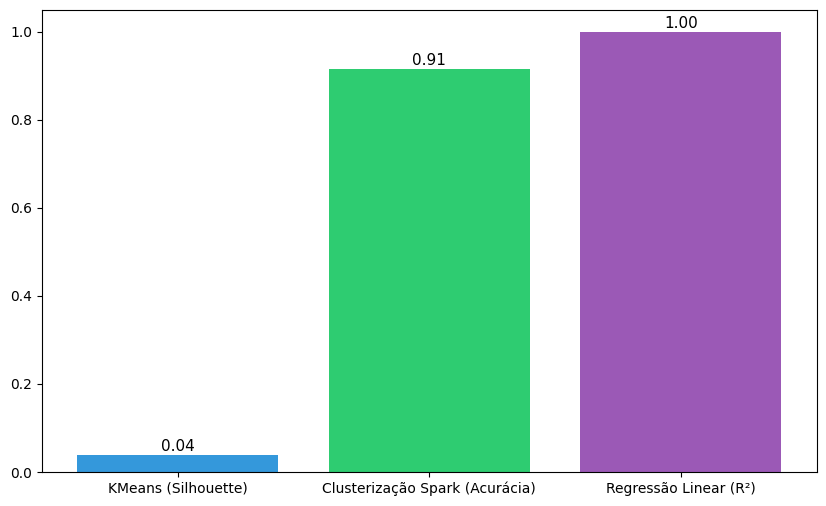

In [66]:
#graficos estaticos para comparação
# Gráfico de Comparação de Modelos
# Preparação dos valores e nomes para os gráficos de barras comparativos.

# Valores para o gráfico
valores_metricas = [
    silhouette_kmeans,            # KMeans
    accuracy_spark,               # Clusterização Spark
    media_r2 if 'media_r2' in locals() else 0  # Regressão Linear (se existir)
]

nomes_modelos = [
    'KMeans (Silhouette)',
    'Clusterização Spark (Acurácia)',
    'Regressão Linear (R²)'
]

# Cores personalizadas
cores = ['#3498db', '#2ecc71', '#9b59b6']

# ==========================================================
#  Gráfico 2: Comparativo de Desempenho dos Modelos
# ==========================================================

# Este gráfico de barras compara o desempenho de diferentes modelos:
# - Silhouette Score do KMeans (para clusterização)
# - Acurácia da Clusterização Spark
# - Média dos R² das Regressões Ridge

#  Por que é importante:
# - Permite visualizar, lado a lado, o desempenho relativo dos diferentes métodos de análise.
# - Ajuda a decidir qual abordagem está performando melhor ou se complementam entre si.

#  Interpretação:
# - Barras mais altas indicam melhor desempenho na respectiva métrica.
# Plotar gráfico de barras
plt.figure(2, figsize=(10,6))
bars = plt.bar(nomes_modelos, valores_metricas, color=cores)

# Adicionar valores no topo das barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.2f}', ha='center', fontsize=11)

# Gráfico de Comparação de Modelos (atualizado com média das regressões)

# Valores para o gráfico
valores_metricas = [
    silhouette_kmeans,            # KMeans
    accuracy_spark,               # Clusterização Spark
    media_r2 if 'media_r2' in locals() else 0  # Média dos R² das Regressões
]

nomes_modelos = [
    'KMeans (Silhouette)',
    'Clusterização Spark (Acurácia)',
    'Regressões (Média R²)'
]

# Cores personalizadas
cores = ['#3498db', '#2ecc71', '#9b59b6']

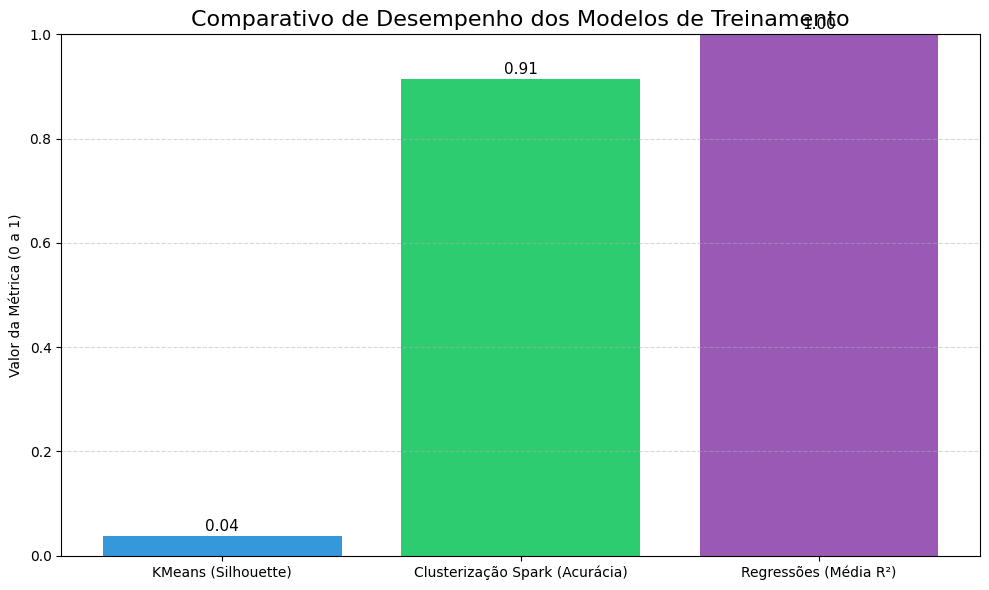

In [67]:
# ==========================================================
#  Gráfico 3: Matriz de Confusão - Spark com Hadoop
# ==========================================================

# Exibe a matriz de confusão do classificador RandomForest treinado com Spark+Hadoop.

#  Por que é importante:
# - Mostra, para cada classe, quantas previsões o modelo acertou e quantas errou.
# - Esclarece onde o modelo está confundindo as categorias (por exemplo, confundindo "Alto" com "Médio").

#  Interpretação:
# - Números na diagonal são acertos.
# - Valores fora da diagonal são erros.
# Plotar gráfico de barras
plt.figure(3, figsize=(10,6))
bars = plt.bar(nomes_modelos, valores_metricas, color=cores)

# Adicionar valores no topo das barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.2f}', ha='center', fontsize=11)

# Configurações gerais
plt.ylim(0, 1)
plt.title('Comparativo de Desempenho dos Modelos de Treinamento', fontsize=16)
plt.ylabel('Valor da Métrica (0 a 1)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()


In [74]:
# ================================
#HADOOP COM O SPARK PARA FACILITAR AS LEITURAS DE DADOS E AGILIZAR O PROCESSAMENTO
# ===============================
# SparkSession COM Hadoop
# ===============================

# Texto explicativo:
# Esta seção utiliza o Apache Spark integrado com o Hadoop (HDFS) para melhorar a eficiência da leitura,
# manipulação e processamento dos dados. O Hadoop é usado para armazenamento distribuído, enquanto o Spark
# oferece processamento distribuído rápido em memória.
# Essa arquitetura permite trabalhar com grandes volumes de dados de forma escalável e performática,
# essencial para o projeto de previsão de risco de evasão escolar.

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import plotly.graph_objects as go # Import plotly for the gauge chart

# Inicializa a sessão Spark (sem configuração HDFS aqui, pois o CSV está local)
spark = SparkSession.builder.appName("PrevisaoRiscoEvasao_CSV").getOrCreate()

# Caminho para o CSV no Colab (depois de montar o Google Drive)
csv_path = "/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv"

# Leitura do CSV pelo Spark
df_spark = spark.read.csv(csv_path, header=True, inferSchema=True, sep=",")

# Mostrar o esquema para ver tipos inferidos
df_spark.printSchema()

# Mostrar as primeiras linhas
df_spark.show(5)


root
 |-- aluno_id: integer (nullable = true)
 |-- nome_aluno: string (nullable = true)
 |-- email_aluno: string (nullable = true)
 |-- curso: string (nullable = true)
 |-- status: string (nullable = true)
 |-- turma: string (nullable = true)
 |-- sexo: string (nullable = true)
 |-- idade: double (nullable = true)
 |-- trabalha: integer (nullable = true)
 |-- renda_familiar: long (nullable = true)
 |-- acompanhamento_medico: integer (nullable = true)
 |-- tem_filho: integer (nullable = true)
 |-- estado_civil: string (nullable = true)
 |-- semestre: integer (nullable = true)
 |-- bimestre: integer (nullable = true)
 |-- aula_1: string (nullable = true)
 |-- professor_1: string (nullable = true)
 |-- notas_1: double (nullable = true)
 |-- faltas_1: integer (nullable = true)
 |-- desempenho_1: string (nullable = true)
 |-- aula_2: string (nullable = true)
 |-- professor_2: string (nullable = true)
 |-- notas_2: double (nullable = true)
 |-- faltas_2: integer (nullable = true)
 |-- desemp

In [75]:
# Definir colunas numéricas e categóricas
colunas_numericas = ["idade", "renda_familiar", "faltas_1", "notas_1", "faltas_2", "notas_2",
                     "faltas_3", "notas_3", "faltas_4", "notas_4", "faltas_5", "notas_5"]
colunas_categoricas = ["sexo", "trabalha", "acompanhamento_medico", "tem_filho",
                       "estado_civil", "desempenho_1", "desempenho_2",
                       "desempenho_3", "desempenho_4", "desempenho_5", "risco_evasao"]

# Converter colunas numéricas para double e preencher valores nulos com -1
for coln in colunas_numericas:
    df_spark = df_spark.withColumn(coln, col(coln).cast("double")).na.fill({coln: -1})

# Preencher valores nulos em colunas categóricas com 'desconhecido' e aplicar StringIndexer
for colc in colunas_categoricas:
    df_spark = df_spark.na.fill({colc: "desconhecido"})
    indexer = StringIndexer(inputCol=colc, outputCol=colc + "_idx", handleInvalid="keep")
    df_spark = indexer.fit(df_spark).transform(df_spark)

# Preparar vetor de features (excluindo a variável alvo "risco_evasao")
feature_cols = colunas_numericas + [col + "_idx" for col in colunas_categoricas[:-1]]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_vec")
df_spark = assembler.transform(df_spark)

# Definir o classificador Random Forest
rf = RandomForestClassifier(labelCol="risco_evasao_idx", featuresCol="features_vec", numTrees=100)

# Treinar o modelo
modelo = rf.fit(df_spark)

# Fazer previsões
predictions = modelo.transform(df_spark)

# Avaliar acurácia
evaluator = MulticlassClassificationEvaluator(
    labelCol="risco_evasao_idx", predictionCol="prediction", metricName="accuracy"
)
accuracy = evaluator.evaluate(predictions)
print(f"Acurácia com Spark + CSV: {accuracy:.4f}")

# Como só temos um único valor de acurácia
fig = go.Figure(go.Indicator(
    mode = "gauge+number",
    value = accuracy * 100,
    title = {'text': "Acurácia do Modelo (%)"},
    gauge = {
        'axis': {'range': [0, 100]},
        'bar': {'color': "green"},
        'steps': [
            {'range': [0, 50], 'color': "red"},
            {'range': [50, 75], 'color': "yellow"},
            {'range': [75, 100], 'color': "lightgreen"}],
    }
))

fig.show()


Acurácia com Spark + CSV: 0.9084


In [76]:
# Exemplo: transformar as previsões para Pandas (somente pequenas amostras, cuidado com grandes datasets)
pdf = predictions.select("prediction", "risco_evasao_idx").toPandas()

# Exemplo: criar gráfico de barras com contagem de acertos e erros
pdf['correto'] = (pdf['prediction'] == pdf['risco_evasao_idx'])

import plotly.express as px
fig2 = px.histogram(pdf, x='correto', title="Distribuição de Acertos e Erros")
fig2.show()


In [81]:
# ==========================================================
# 📊 Gráfico 4: Distribuição Real vs Predita - Hadoop
# ==========================================================

# Compara a distribuição de riscos reais e preditos para avaliar se o modelo está desbalanceado.

# 📌 Por que é importante:
# - Revela se o modelo está prevendo mais ou menos categorias do que deveria.
# - Diagnostica tendências de enviesamento ou desbalanceamento.

# 📌 Interpretação:
# - Se as barras de Real e Predito forem similares em altura para cada classe, o modelo está bem balanceado.
# - Diferenças indicam viés.
# Converter as previsões do Spark para Pandas
preds_pd = predictions.select("risco_evasao_idx", "prediction").toPandas()

# Gerar a matriz de confusão
conf_mat = confusion_matrix(preds_pd["risco_evasao_idx"], preds_pd["prediction"])

# Definir labels para as classes (substitua pelos nomes reais se tiver)
labels = [str(i) for i in range(conf_mat.shape[0])]

# Criar gráfico interativo da matriz de confusão
fig = ff.create_annotated_heatmap(
    z=conf_mat,
    x=labels,
    y=labels,
    colorscale='Blues',
    showscale=True,
    annotation_text=conf_mat.astype(str),
    hoverinfo='z'
)

fig.update_layout(
    title="Matriz de Confusão - Spark com CSV (Interativo)",
    xaxis_title="Predito",
    yaxis_title="Real"
)

fig.show()


In [83]:
# ==========================================================
# 📊 Gráfico 5: Importância das Variáveis - RandomForest Spark
# ==========================================================

# Exibe as 10 variáveis mais importantes para a previsão do risco de evasão, segundo o RandomForest do Spark.

#  Por que é importante:
# - Permite entender quais atributos mais influenciam as predições.
# - Orienta gestores acadêmicos a priorizarem fatores mais críticos (ex: número de faltas, notas).

#  Interpretação:
# - Variáveis com maior importância contribuem mais para as decisões do modelo.
# - Essencial para transparência e explicabilidade em ML.
# Distribuição das classes reais versus preditas para verificar desequilíbrios e vieses.
# Criar dataframe com as importâncias das features (top 10)
# Corrected variable names from modelo_hadoop and assembler_hadoop to modelo and assembler
importances_hadoop = modelo.featureImportances.toArray()
feature_names_hadoop = assembler.getInputCols()

df_importancias = pd.DataFrame({
    'Variável': feature_names_hadoop,
    'Importância': importances_hadoop
}).sort_values(by='Importância', ascending=False).head(10)

# Gráfico interativo da importância das variáveis
fig_importance = px.bar(
    df_importancias,
    x='Importância',
    y='Variável',
    orientation='h',
    title='Top 10 Variáveis mais Importantes - Random Forest (Spark)',
    labels={'Importância': 'Importância', 'Variável': 'Variável'},
    text='Importância'
)

fig_importance.update_layout(yaxis={'categoryorder':'total ascending'})
fig_importance.show()

# Now the graph of the real vs predicted distribution of the evasion risk classes
# Corrected variable name from predictions_hadoop to predictions
preds_hadoop_pd = predictions.select("risco_evasao_idx", "prediction").toPandas()

# Contagem para classes reais
real_counts = preds_hadoop_pd['risco_evasao_idx'].value_counts().sort_index()
# Contagem para classes preditas
pred_counts = preds_hadoop_pd['prediction'].value_counts().sort_index()

fig_dist = go.Figure()
fig_dist.add_trace(go.Bar(
    x=real_counts.index.astype(str),
    y=real_counts.values,
    name='Real',
    marker_color='royalblue',
    opacity=0.7
))
fig_dist.add_trace(go.Bar(
    x=pred_counts.index.astype(str),
    y=pred_counts.values,
    name='Predito',
    marker_color='tomato',
    opacity=0.5
))

fig_dist.update_layout(
    title="Distribuição das Classes: Real vs Predita (Hadoop)",
    xaxis_title="Risco de Evasão",
    yaxis_title="Quantidade",
    barmode='overlay',
    legend=dict(x=0.7, y=0.95)
)

fig_dist.show()

<ipython-input-84-8e214fe53196>:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




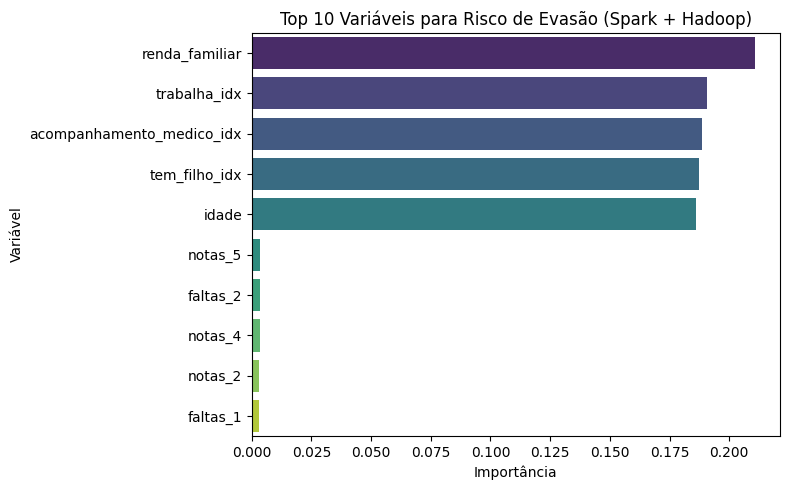

In [84]:
# ==========================================================
#  Gráfico 6: Top 10 Variáveis mais Importantes (Spark + Hadoop)
# ==========================================================

#  O que este gráfico mostra:
# Exibe as 10 variáveis mais importantes, segundo o RandomForest treinado com Spark e Hadoop,
# para a previsão do risco de evasão.

#  Por que é importante:
# - Permite identificar quais atributos do aluno mais influenciam as predições do modelo.
# - Direciona a tomada de decisão da instituição para as variáveis mais críticas.
# - É fundamental para explicar o modelo (explainability) e garantir transparência nas análises.

#  Como interpretar:
# - As barras representam a importância relativa de cada variável.
# - Quanto maior a barra, maior o impacto daquela variável nas predições do modelo.
plt.figure(6, figsize=(8, 5))
sns.barplot(x="Importância", y="Variável", data=df_importancias, palette="viridis")
plt.title("Top 10 Variáveis para Risco de Evasão (Spark + Hadoop)")
plt.tight_layout()


# Percentual de predições por categoria para entender a distribuição prevista pelo modelo.
percentuais_pred = preds_hadoop_pd["prediction"].value_counts(normalize=True) * 100
df_percentual = percentuais_pred.reset_index()
df_percentual.columns = ['Categoria Predita', 'Percentual']

<ipython-input-85-970e7c2bce19>:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




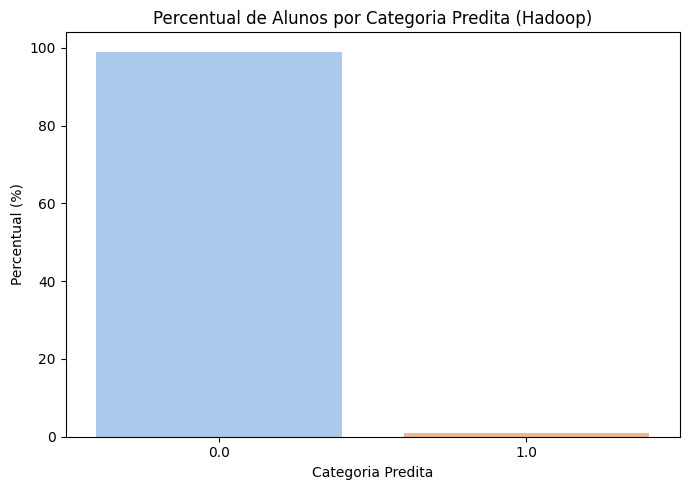

In [85]:
# ==========================================================
#  Gráfico 7: Percentual de Alunos por Categoria Predita (Hadoop)
# ==========================================================

#  O que este gráfico mostra:
# Um gráfico de barras com o percentual de alunos classificados pelo modelo em cada categoria de risco.

#  Por que é importante:
# - Permite analisar se o modelo está prevendo categorias de forma equilibrada ou enviesada.
# - Ajuda a identificar se o modelo tende a superestimar ou subestimar certas classes.
# - É essencial para validar a distribuição predita versus a esperada.

#  Como interpretar:
# - Barras com percentuais muito altos ou muito baixos podem indicar um viés.
# - Se as classes minoritárias aparecem muito pouco, pode ser sinal de que o modelo precisa de mais balanceamento.
plt.figure(7, figsize=(7,5))
sns.barplot(x='Categoria Predita', y='Percentual', data=df_percentual, palette="pastel")
plt.title("Percentual de Alunos por Categoria Predita (Hadoop)")
plt.ylabel("Percentual (%)")
plt.xlabel("Categoria Predita")
plt.tight_layout()

# =============================== FIM HADOOP COM O SPARK ===============================

Relatório Final (5 Aulas):
              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00       0.0
       Baixo       0.00      0.00      0.00       0.0
         Bom       0.00      0.00      0.00     130.0
   Excelente       0.00      0.00      0.00      94.0
       Médio       0.00      0.00      0.00       0.0
     Regular       0.00      0.00      0.00     466.0
        Ruim       0.00      0.00      0.00    1310.0

    accuracy                           0.00    2000.0
   macro avg       0.00      0.00      0.00    2000.0
weighted avg       0.00      0.00      0.00    2000.0



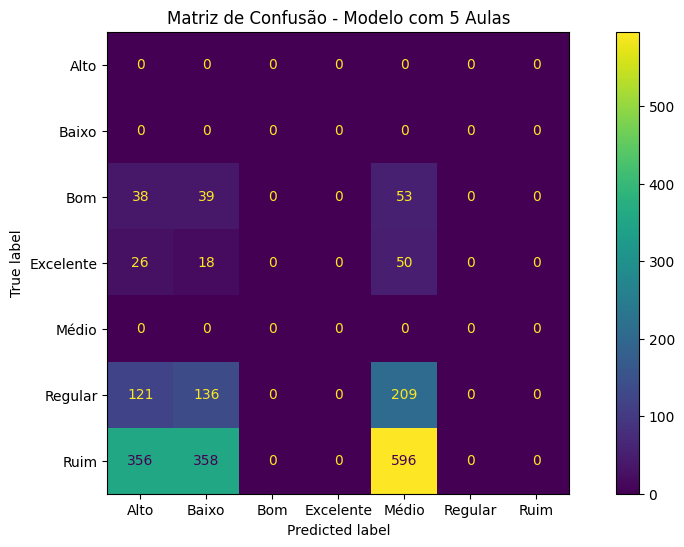

In [87]:
# Gráficos Estáticos para análise do modelo e dados de evasão escolar
# ================================================================
# Gráfico 1: Relatório Final de Classificação (5 Aulas)
# ================================================================

#  O que faz:
# Imprime o relatório de métricas de desempenho do modelo RandomForest, considerando as 5 aulas.

#  Por que é importante:
# - Avalia o desempenho geral e individual por classe.
# - Mostra as métricas de precisão, recall, f1-score e suporte.
# - Permite identificar onde o modelo é bom e onde precisa melhorar.

#  Como interpretar:
# - Precisão: taxa de acerto entre os positivos preditos.
# - Recall: taxa de acerto entre os positivos reais.
# - F1-score: equilíbrio entre precisão e recall.
# - Suporte: quantidade de casos reais em cada classe.
labels = sorted(set(y_test) | set(y_pred))

print("Relatório Final (5 Aulas):")
print(classification_report(y_test, y_pred, labels=labels, zero_division=0))

# Plotar a matriz de confusão com todas as classes
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=labels)
plt.gcf().set_size_inches(12, 6)
plt.title("Matriz de Confusão - Modelo com 5 Aulas")
plt.show()

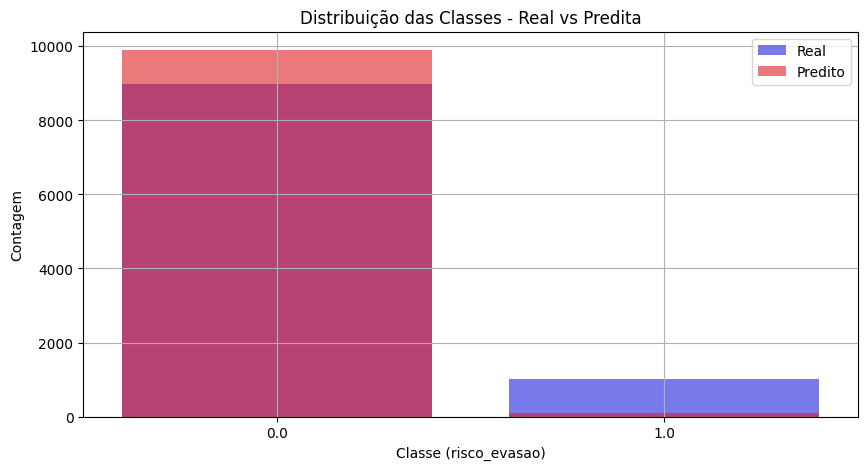

In [88]:
# ================================================================
#  Gráfico 2: Matriz de Confusão (via ConfusionMatrixDisplay)
# ================================================================

#  O que faz:
# Exibe a matriz de confusão para o modelo de classificação.

#  Por que é importante:
# - Mostra a quantidade de acertos e erros do modelo por categoria.
# - Facilita identificar em quais classes o modelo confunde mais.

#  Como interpretar:
# - Valores na diagonal são acertos.
# - Valores fora da diagonal são erros.
# - Permite avaliar o equilíbrio e precisão por categoria.
plt.figure(9, figsize=(10, 5))
sns.countplot(data=preds_pd, x="risco_evasao_idx", color="blue", label="Real", alpha=0.6)
sns.countplot(data=preds_pd, x="prediction", color="red", label="Predito", alpha=0.6)
plt.title("Distribuição das Classes - Real vs Predita")
plt.xlabel("Classe (risco_evasao)")
plt.ylabel("Contagem")
plt.legend()
plt.grid(True)


Text(70.72222222222221, 0.5, 'Real')

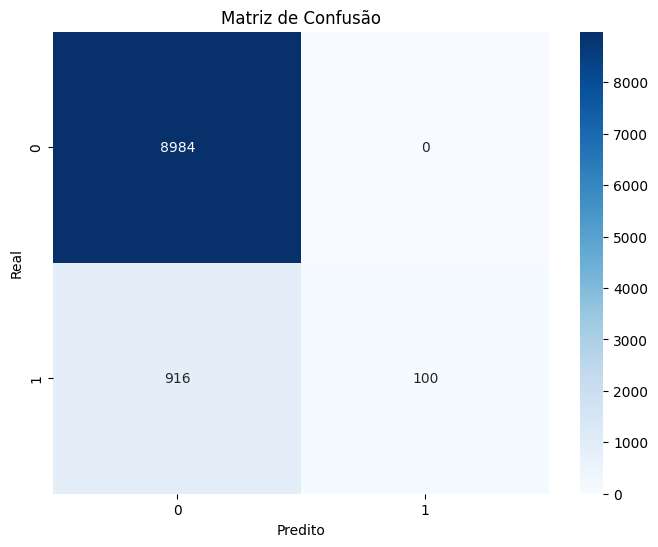

In [89]:
# ================================================================
#  Gráfico 3: Distribuição das Classes - Real vs Predita
# ================================================================

#  O que faz:
# Compara graficamente a quantidade de registros em cada categoria de risco de evasão,
# tanto nos dados reais quanto nos preditos pelo modelo.

#  Por que é importante:
# - Permite visualizar se o modelo está favorecendo alguma classe (viés).
# - Verifica se o modelo está desbalanceado na previsão de certas categorias.

#  Como interpretar:
# - Barras próximas em altura indicam boa correspondência.
# - Diferenças grandes sugerem que o modelo está superestimando ou subestimando alguma categoria.
plt.figure(10, figsize=(8, 6))
conf_mat = confusion_matrix(preds_pd["risco_evasao_idx"], preds_pd["prediction"])
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")

Text(0.5, 1.0, 'Acurácia do Modelo de Evasão')

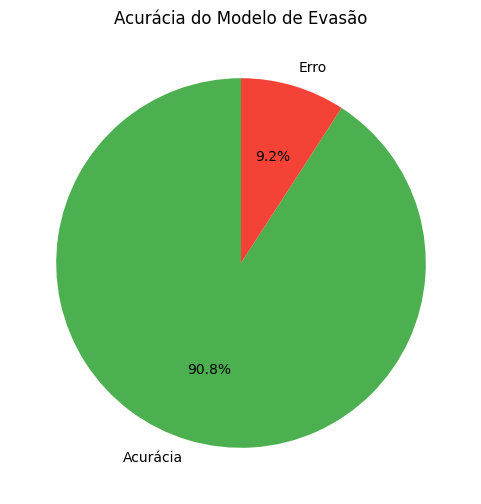

In [90]:
# ================================================================
#  Gráfico 4: Matriz de Confusão (heatmap via Seaborn)
# ================================================================

#  O que faz:
# Mostra a matriz de confusão como um heatmap, tornando a interpretação mais visual e intuitiva.

#  Por que é importante:
# - Visualização gráfica facilita identificar rapidamente onde estão os maiores erros e acertos.
# - As cores ajudam a localizar os pontos de maior concentração.

#  Como interpretar:
# - Quadrados mais escuros representam maior número de ocorrências.
# - A diagonal idealmente deve ser a mais escura (maior acerto).
labels = ['Acurácia', 'Erro']
sizes = [accuracy, 1 - accuracy]
plt.figure(11, figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#F44336'])
plt.title('Acurácia do Modelo de Evasão')


<ipython-input-91-8a531b243e5f>:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




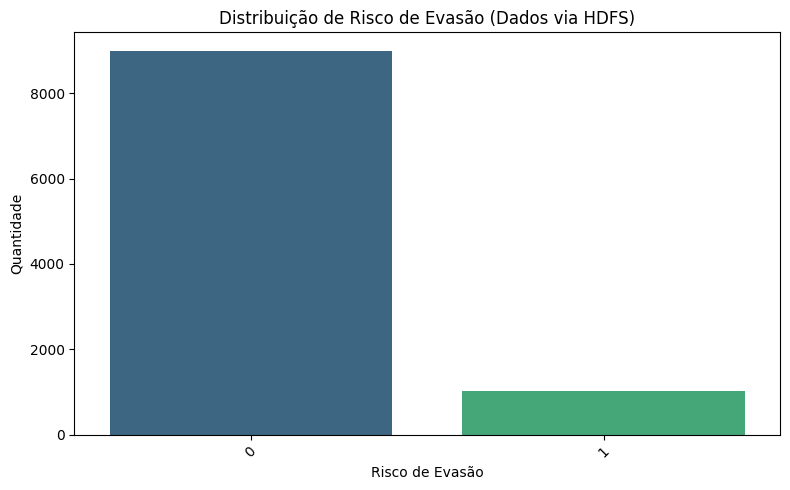

In [91]:
# ================================================================
#  Gráfico 5: Distribuição de Risco de Evasão (dados via HDFS)
# ================================================================

#  O que faz:
# Mostra a frequência de cada categoria de risco (Baixo, Médio, Alto) diretamente dos dados brutos carregados via HDFS.

#  Por que é importante:
# - Permite entender a distribuição original da base antes de qualquer pré-processamento ou modelagem.
# - Essencial para identificar desbalanceamento entre as classes.

#  Como interpretar:
# - Se uma categoria domina o gráfico, há desbalanceamento.
# - Uma distribuição equilibrada facilita o aprendizado de modelos de machine learning.
plt.figure(12, figsize=(8, 5))
sns.countplot(data=df_pandas, x='risco_evasao', palette='viridis')
plt.title('Distribuição de Risco de Evasão (Dados via HDFS)')
plt.xlabel('Risco de Evasão')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()


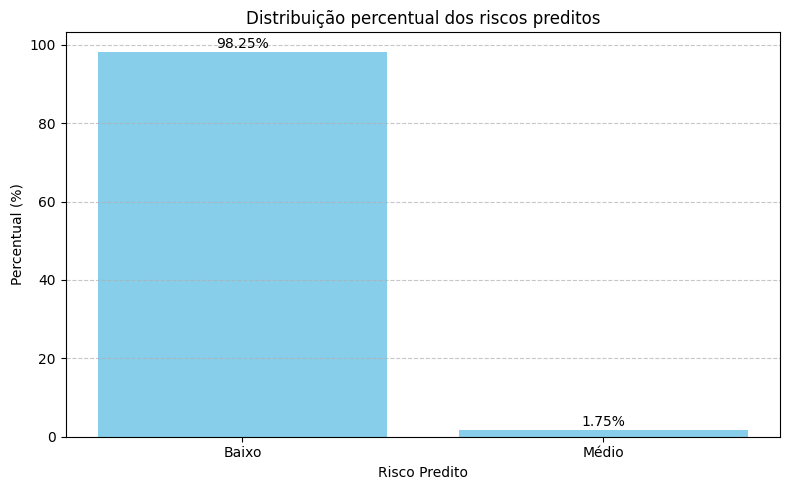

In [92]:
# ================================================================
# 📊 Gráfico 6: Distribuição Percentual dos Riscos Preditos
# ================================================================

#  O que faz:
# Mostra, em percentual, a quantidade de predições que o modelo fez para cada categoria de risco.

#  Por que é importante:
# - Permite verificar se o modelo está favorecendo alguma categoria.
# - Avalia se o modelo distribui bem suas predições ou concentra tudo em uma só.

#  Como interpretar:
# - Barras muito altas ou baixas indicam possíveis desequilíbrios ou viés do modelo.
# - Um modelo ideal deve refletir, na medida do possível, a distribuição original ou corrigida.
plt.figure(13, figsize=(8,5))
bars = plt.bar(df_risco_counts['risco_predito'], df_risco_counts['percentual'], color='skyblue')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.2f}%', ha='center')
plt.title('Distribuição percentual dos riscos preditos')
plt.xlabel('Risco Predito')
plt.ylabel('Percentual (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

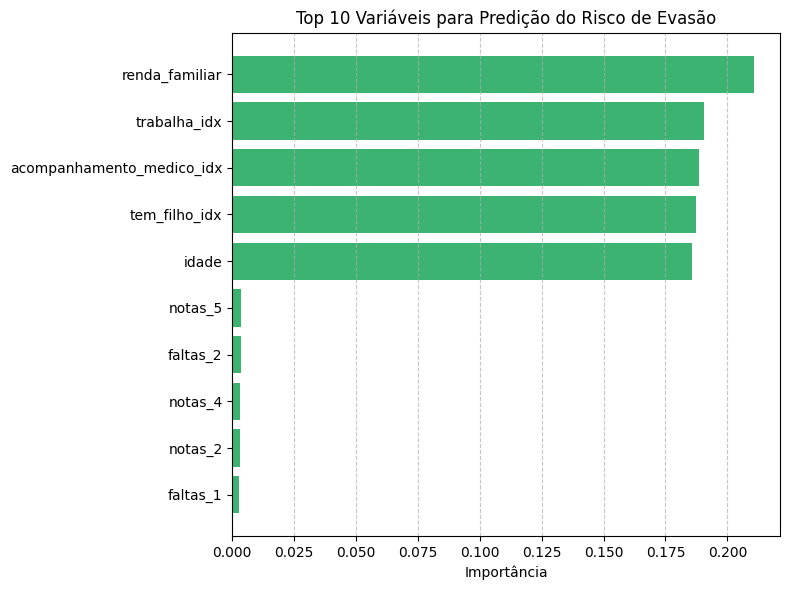

In [93]:
# ================================================================
#  Gráfico 7: Top 10 Variáveis para Predição do Risco de Evasão
# ================================================================

#  O que faz:
# Exibe as 10 variáveis mais relevantes segundo o RandomForest para a predição do risco de evasão.

#  Por que é importante:
# - Permite interpretar o comportamento do modelo.
# - Identifica os fatores que mais influenciam o risco de evasão.
# - Essencial para validação e explicabilidade de modelos de machine learning.

#  Como interpretar:
# - Quanto maior a barra, maior a importância da variável no modelo.
# - Variáveis no topo devem ser monitoradas de perto pela gestão acadêmica.
top_imp = df_imp.head(10)
plt.figure(14, figsize=(8,6))
plt.barh(top_imp['Variável'], top_imp['Importância'], color='mediumseagreen')
plt.xlabel('Importância')
plt.title('Top 10 Variáveis para Predição do Risco de Evasão')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

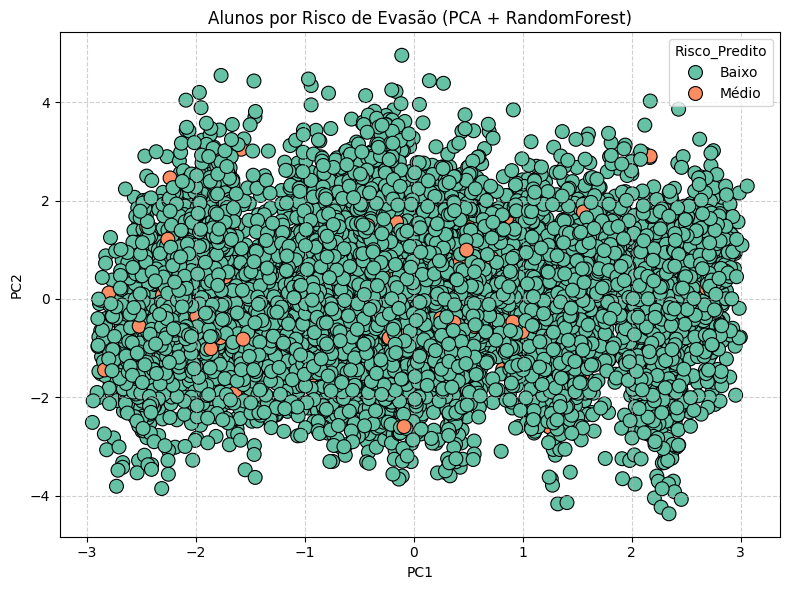

In [94]:
# ================================================================
#  Gráfico 8: Alunos por Risco de Evasão (PCA + RandomForest)
# ================================================================

#  O que faz:
# Visualização bidimensional dos alunos baseada em PCA (redução de dimensionalidade), colorindo por categoria de risco predita.

#  Por que é importante:
# - Facilita a análise exploratória, mostrando como os grupos se separam espacialmente.
# - Ajuda a validar se as categorias de risco formam clusters ou estão misturadas.

#  Como interpretar:
# - Pontos agrupados e bem separados indicam boa capacidade do modelo em distinguir categorias.
# - Se tudo estiver misturado, o modelo ou os dados podem precisar de ajustes.
plt.figure(15, figsize=(8,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Risco_Predito', palette='Set2', s=100, edgecolor='black')
plt.title('Alunos por Risco de Evasão (PCA + RandomForest)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


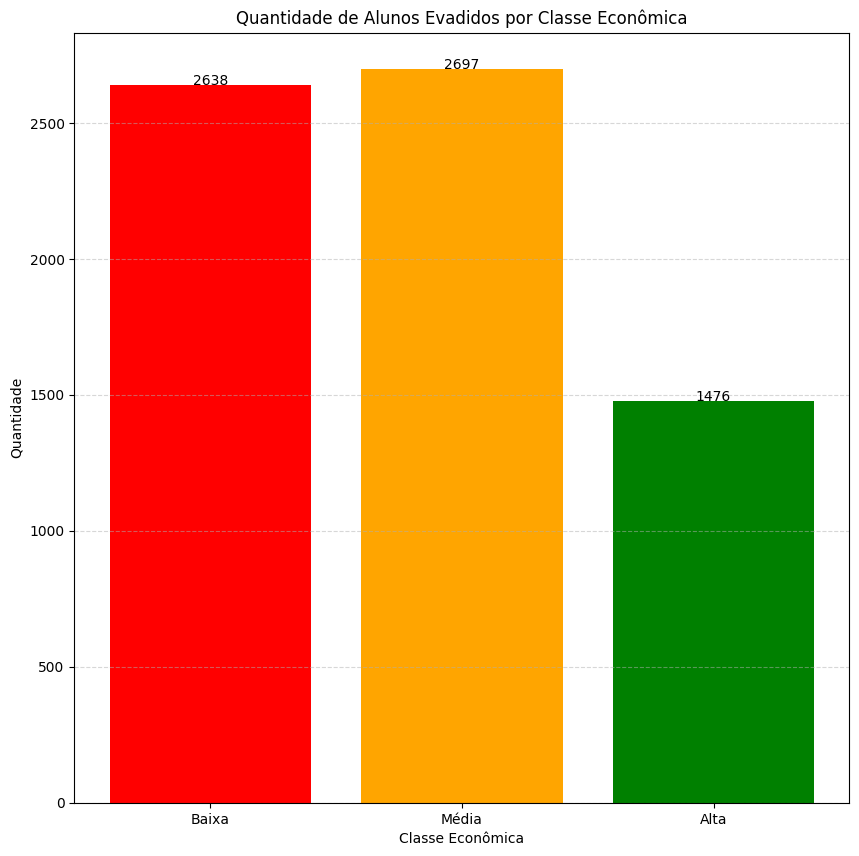

In [95]:
# ================================================================
#  Gráfico 9: Quantidade de alunos evadidos por classe econômica
# ================================================================

#  O que faz:
# Mostra a quantidade de alunos que evadiram em cada faixa de classe econômica (Baixa, Média, Alta).

#  Por que é importante:
# - Ajuda a investigar a relação entre condição socioeconômica e evasão escolar.
# - Permite orientar políticas de apoio financeiro e acadêmico.

#  Como interpretar:
# - Barras mais altas em determinada faixa indicam maior incidência de evasão naquele grupo.
# - Caso a evasão se concentre em uma faixa, sugere vulnerabilidade social específica.
plt.figure(16, figsize=(10,10))
colors = ['red', 'orange', 'green']
bars = plt.bar(df_contagem['classe_economica'], df_contagem['quantidade_evadidos'], color=colors)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(int(height)), ha='center')
plt.title('Quantidade de Alunos Evadidos por Classe Econômica')
plt.xlabel('Classe Econômica')
plt.ylabel('Quantidade')
plt.grid(axis='y', linestyle='--', alpha=0.5)

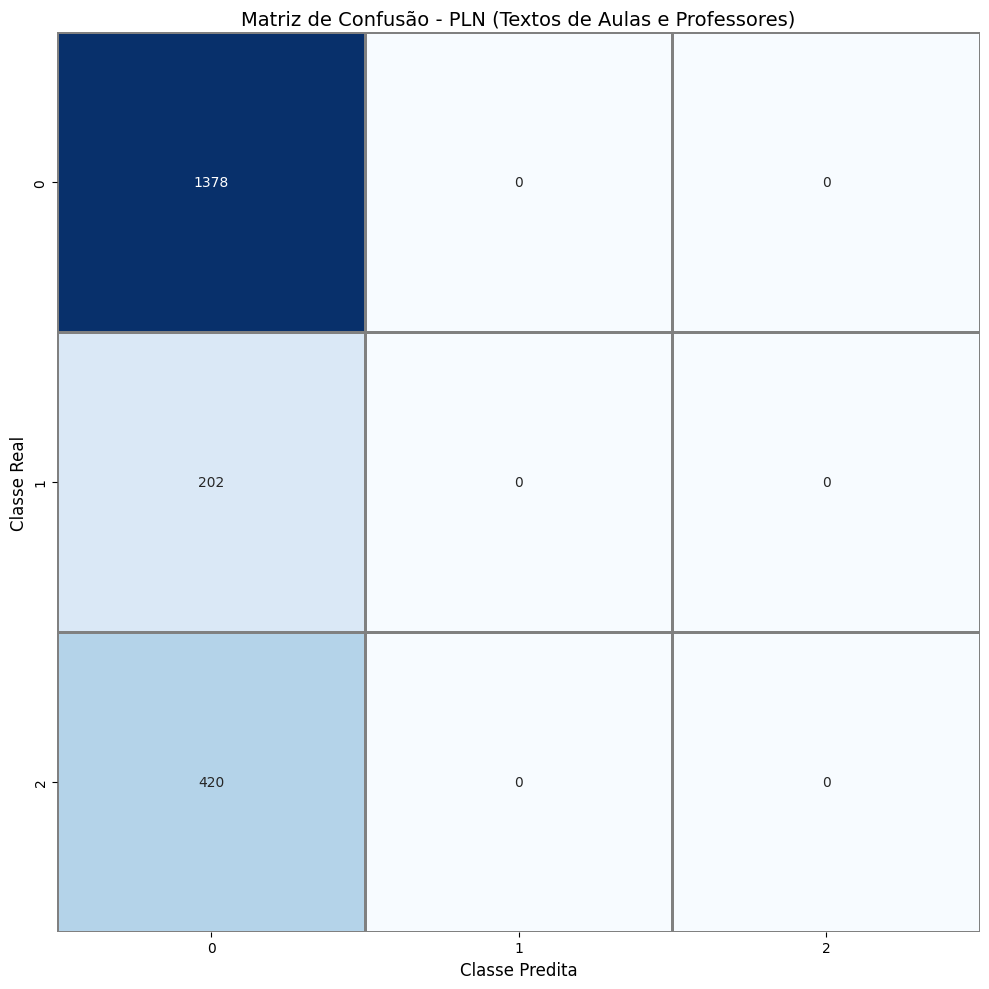

In [96]:
# ================================================================
#  Gráfico 10: Matriz de Confusão (PLN – Textos de Aulas e Professores)
# ================================================================

#  O que faz:
# Apresenta a matriz de confusão do modelo de Processamento de Linguagem Natural (PLN)
# usado para classificar risco de evasão com base em textos das aulas e professores.

#  Por que é importante:
# - Permite visualizar quais classes estão sendo corretamente ou erroneamente classificadas.
# - Ajuda a detectar pontos fracos no modelo de texto.

#  Como interpretar:
# - Diagonal principal forte (valores altos) significa boa acurácia.
# - Valores altos fora da diagonal representam erros de classificação.
plt.figure(17, figsize=(10, 10))
conf_mat = confusion_matrix(y_test_txt, y_pred_txt)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=1, linecolor='gray')
plt.title('Matriz de Confusão - PLN (Textos de Aulas e Professores)', fontsize=14)
plt.xlabel('Classe Predita', fontsize=12)
plt.ylabel('Classe Real', fontsize=12)
plt.tight_layout()
plt.grid(False)


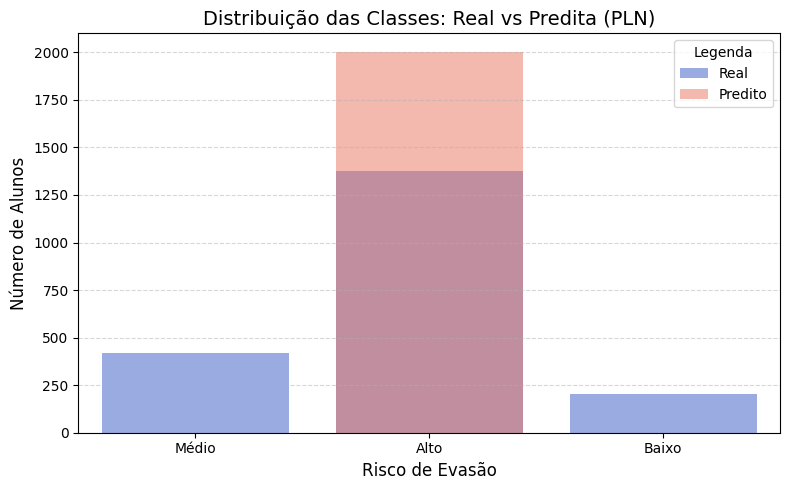

In [97]:
# ================================================================
#  Gráfico 11: Distribuição Real vs Predito (PLN)
# ================================================================

#  O que faz:
# Compara a quantidade de predições feitas pelo modelo PLN com as classes reais.

#  Por que é importante:
# - Diagnostica viés ou tendência do modelo em prever mais ou menos para determinada classe.
# - Fundamental para análise de fairness e equilíbrio.

#  Como interpretar:
# - Barras próximas indicam boa calibragem.
# - Diferenças grandes indicam viés ou sobreajuste.
plt.figure(18, figsize=(8, 5))
sns.countplot(x=y_test_txt, label='Real', alpha=0.6, color='royalblue')
sns.countplot(x=y_pred_txt, label='Predito', alpha=0.5, color='tomato')
plt.legend(title='Legenda')
plt.title('Distribuição das Classes: Real vs Predita (PLN)', fontsize=14)
plt.xlabel('Risco de Evasão', fontsize=12)
plt.ylabel('Número de Alunos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()


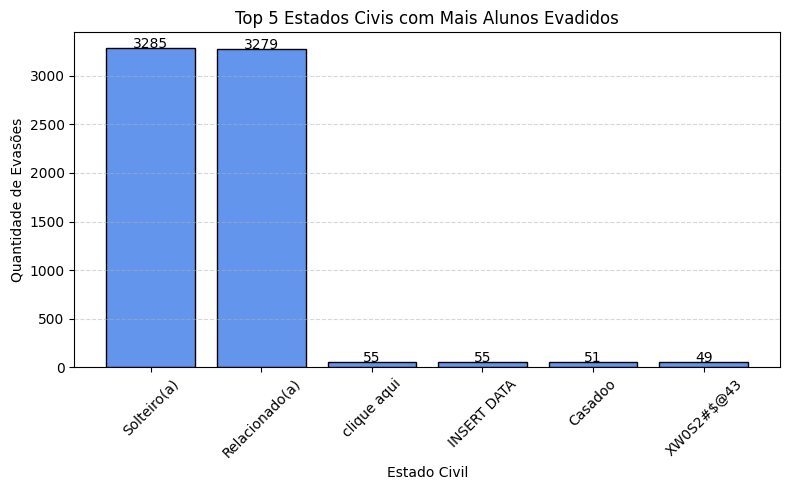

In [98]:
# ================================================================
#  Gráfico 12: Top 5 Estados Civis com Mais Evasão
# ================================================================

#  O que faz:
# Mostra os estados civis com maior incidência de evasão.

#  Por que é importante:
# - Identifica se determinada condição familiar (ex: casado, solteiro) influencia na evasão.
# - Pode guiar políticas institucionais e psicopedagógicas.

#  Como interpretar:
# - Barras mais altas indicam estados civis com mais evasão.
# - Pode-se analisar a necessidade de suporte para alunos dessas categorias.
df_estado = df.dropna(subset=['estado_civil', 'risco_evasao'])
evasao_estado = df_estado[
    df_estado['risco_evasao'].astype(str).str.lower().isin(['1', 'alto'])]['estado_civil'].value_counts().nlargest(6)
plt.figure(19, figsize=(8,5))
bars = plt.bar(evasao_estado.index, evasao_estado.values, color='cornflowerblue', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(int(height)), ha='center')
plt.title('Top 5 Estados Civis com Mais Alunos Evadidos')
plt.xlabel('Estado Civil')
plt.ylabel('Quantidade de Evasões')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()


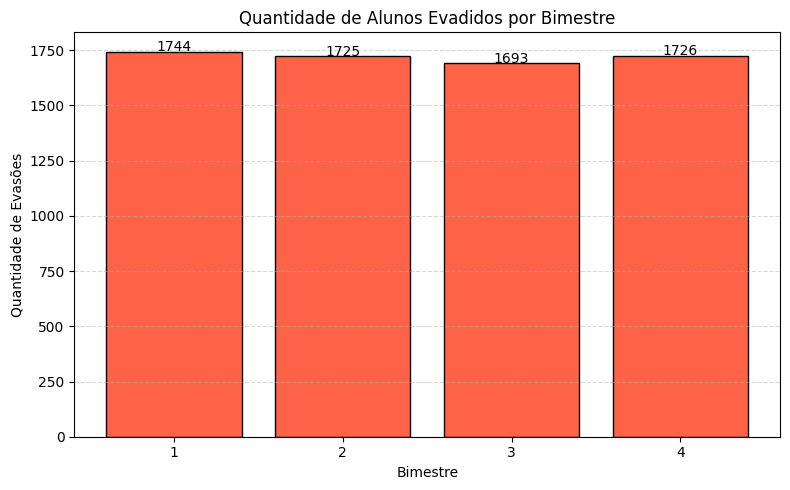

In [99]:
# ================================================================
#  Gráfico 13: Evasão por Bimestre
# ================================================================

#  O que faz:
# Mostra a quantidade de evasões em cada bimestre, permitindo identificar períodos críticos do ano letivo.

#  Por que é importante:
# - Identifica em quais bimestres os alunos mais desistem.
# - Permite direcionar ações específicas para esses períodos.

#  Como interpretar:
# - Barras mais altas indicam bimestres com maior evasão.
# - Pode revelar efeitos sazonais ou problemas recorrentes.
df_bimestre = df.dropna(subset=['bimestre', 'risco_evasao'])
evasao_bimestre = df_bimestre[
    df_bimestre['risco_evasao'].astype(str).str.lower().isin(['1', 'alto'])]['bimestre'].value_counts().sort_index()
plt.figure(20, figsize=(8,5))
bars = plt.bar(evasao_bimestre.index.astype(str), evasao_bimestre.values, color='tomato', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(int(height)), ha='center')
plt.title('Quantidade de Alunos Evadidos por Bimestre')
plt.xlabel('Bimestre')
plt.ylabel('Quantidade de Evasões')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

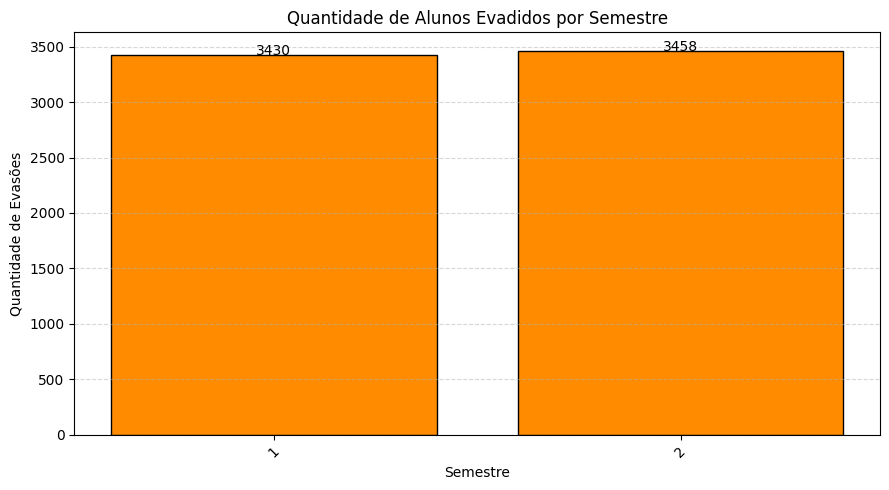

In [100]:
# ================================================================
#  Gráfico 14: Evasão por Semestre
# ================================================================

#  O que faz:
# Mostra a quantidade de evasões por semestre, agrupando os dados em períodos maiores.

#  Por que é importante:
# - Detecta tendências ao longo dos semestres.
# - Facilita análises de médio prazo para planejamento acadêmico.

#  Como interpretar:
# - Barras mais altas indicam semestres com maior evasão.
# - Permite comparar períodos letivos completos.
df_semestre = df.dropna(subset=['semestre', 'risco_evasao'])
evasao_semestre = df_semestre[
    df_semestre['risco_evasao'].astype(str).str.lower().isin(['1', 'alto'])]['semestre'].value_counts().sort_index()
plt.figure(21, figsize=(9,5))
bars = plt.bar(evasao_semestre.index.astype(str), evasao_semestre.values, color='darkorange', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(int(height)), ha='center')
plt.title('Quantidade de Alunos Evadidos por Semestre')
plt.xlabel('Semestre')
plt.ylabel('Quantidade de Evasões')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()


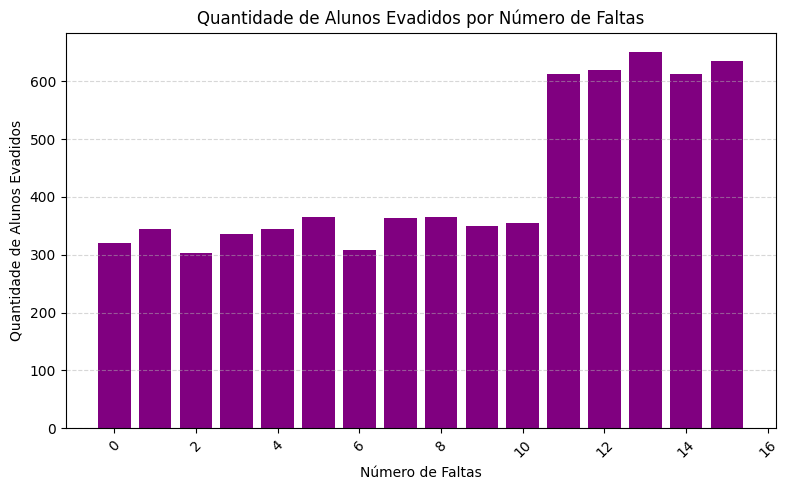

In [101]:
# ================================================================
#  Gráfico 15: Alunos Evadidos por Número de Faltas
# ================================================================

#  O que faz:
# Exibe a quantidade de alunos evadidos de acordo com o número de faltas acumuladas.

#  Por que é importante:
# - Verifica se faltas excessivas estão relacionadas à evasão.
# - Pode embasar políticas de presença obrigatória ou reforço.

#  Como interpretar:
# - Maior número de evasões em faixas altas de faltas indica forte correlação.
plt.figure(22, figsize=(8,5))
plt.bar(df_faltas_count['faltas_1'], df_faltas_count['quantidade_evadidos'], color='purple')
plt.title('Quantidade de Alunos Evadidos por Número de Faltas')
plt.xlabel('Número de Faltas')
plt.ylabel('Quantidade de Alunos Evadidos')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()


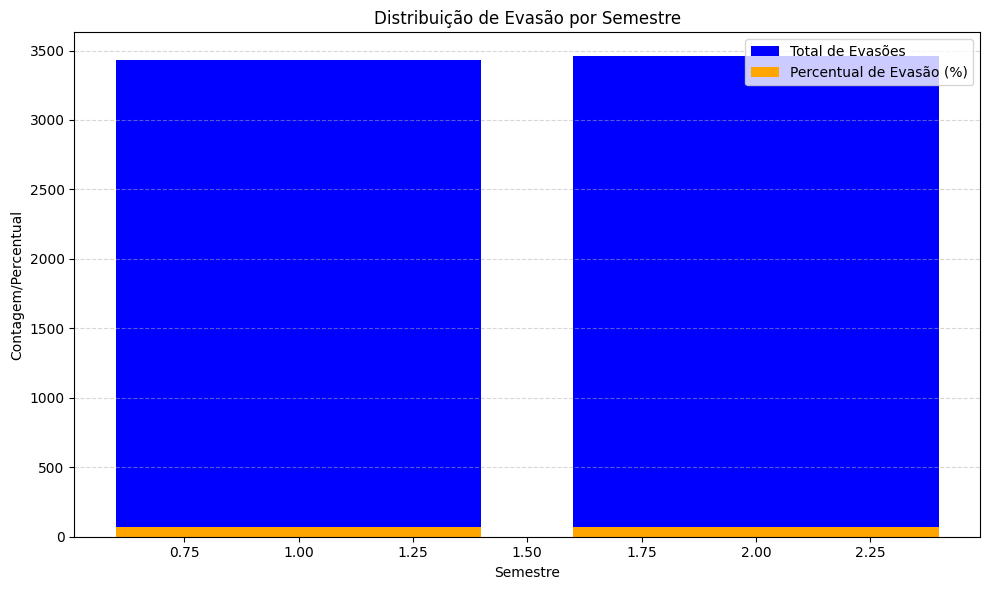

In [104]:
# ================================================================
#  Gráfico 16: Evasão por Semestre (Total e Percentual)
# ================================================================

#  O que faz:
# Exibe, lado a lado, a quantidade absoluta de evasões e o percentual de evasão por semestre.

#  Por que é importante:
# - Oferece visão completa: tanto volume bruto quanto proporção em relação ao total de alunos.
# - Ajuda a identificar se semestres com menos alunos têm percentuais altos.

#  Como interpretar:
# - Barras azuis: total de evasões.
# - Barras laranjas: percentual de evasão.
plt.figure(23, figsize=(10,6))
plt.bar(dados_plot['semestre'], dados_plot['total_evasoes'], color='blue', label='Total de Evasões')
plt.bar(dados_plot['semestre'], dados_plot['percentual_evasao'], color='orange', label='Percentual de Evasão (%)')
plt.title('Distribuição de Evasão por Semestre')
plt.xlabel('Semestre')
plt.ylabel('Contagem/Percentual')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# ================================================================
#  Preparação: Análise dos Motivos de Evasão
# ================================================================

#  O que faz:
# Cria uma coluna categórica 'motivo_evasao' aplicando uma função customizada para categorizar o motivo da evasão.
# Agrupa os dados para contabilizar a quantidade de evasões por motivo e nível de risco.

#  Por que é importante:
# - Entender os motivos ajuda a direcionar ações específicas (financeiras, pedagógicas, psicológicas).
# - Permite verificar se os principais motivos estão alinhados com os perfis de risco identificados.

if 'df_motivos' not in locals():
    df_model['motivo_evasao'] = df_model.apply(definir_motivo, axis=1)
    df_motivos = df_model.groupby(['risco_predito', 'motivo_evasao']).size().reset_index(name='quantidade')


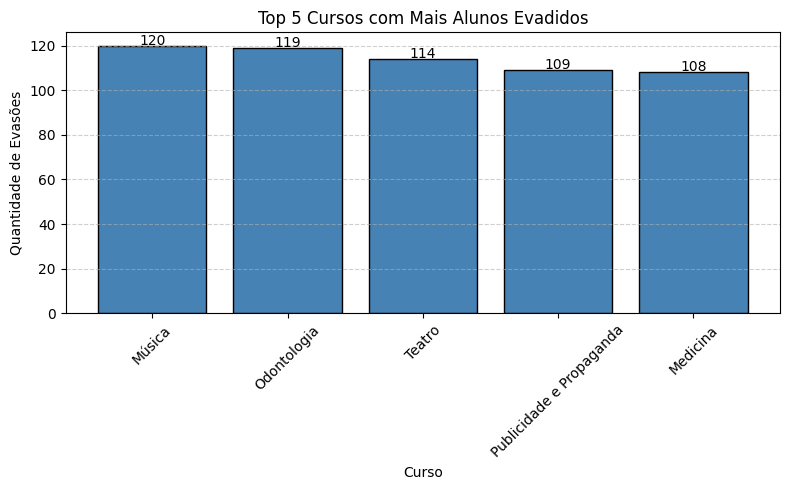

In [103]:
# Gráfico 17: Top 5 cursos com mais evasão
# Este gráfico de barras exibe os cinco cursos com maior número de alunos evadidos classificados como risco alto de evasão.
# A análise é realizada filtrando o DataFrame para considerar apenas alunos com risco de evasão alto e curso definido,
# contando as ocorrências de evasão por curso e selecionando os cinco com maior contagem.
# A visualização auxilia na identificação dos cursos com maior problema de evasão,
# permitindo priorizar ações e alocação de recursos para estratégias de retenção específicas.
# As barras mostram a quantidade de evasões, com valores numéricos acima para facilitar a leitura precisa.
df_evasao_curso = df.copy()
df_evasao_curso = df_evasao_curso.dropna(subset=['risco_evasao', 'curso'])
df_evadidos = df_evasao_curso[df_evasao_curso['risco_evasao'].astype(str).str.lower().isin(['1', 'alto'])]
top_cursos = df_evadidos['curso'].value_counts().nlargest(5)
plt.figure(24, figsize=(8, 5))
bars = plt.bar(top_cursos.index, top_cursos.values, color='steelblue', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(int(height)), ha='center')
plt.title('Top 5 Cursos com Mais Alunos Evadidos')
plt.xlabel('Curso')
plt.ylabel('Quantidade de Evasões')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()
